# Analisis Model Prediksi Keberhasilan Pengobatan MDR-TB
## Notebook untuk Menghasilkan Figur Publikasi Disertasi

Notebook ini menghasilkan semua figur dan tabel yang dibutuhkan untuk bab Hasil & Pembahasan disertasi.

**Sections:**
1. Setup & Data Loading
2. Exploratory Data Analysis (EDA)
3. Class Imbalance Analysis
4. Model Training & Evaluation
5. Bootstrap 95% Confidence Intervals
6. ROC & Precision-Recall Curves
7. Confusion Matrix Heatmaps
8. Calibration Curves & Brier Scores
9. Feature Importance & Odds Ratio Forest Plot
10. SHAP Interpretability
11. Nested Cross-Validation
12. Sensitivity Analysis
13. Export All Figures

In [1]:
# ============================
# 1. Setup & Data Loading
# ============================
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Publication-quality settings
matplotlib.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.figsize': (8, 6),
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
})
sns.set_style('whitegrid')
sns.set_palette('Set2')

PROJECT_ROOT = Path(os.getcwd()).parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

FIGURES_DIR = Path('figures')
FIGURES_DIR.mkdir(exist_ok=True)

from preprocessing import DataPreprocessor
from training import ModelTrainer
from evaluation import ModelEvaluator
from interpretability import (
    get_all_interpretability, get_class_distribution,
    get_lr_odds_ratios, get_tree_feature_importance,
    get_permutation_importance_data
)

preprocessor = DataPreprocessor()

# Fitur yang digunakan untuk training tapi TIDAK ditampilkan di visualisasi
# (karena tidak ada di form input web app)
HIDDEN_FEATURES = ['Ket.Usia', 'BB', 'TB', 'IMT']

print("Setup complete.")
print(f"Project root: {PROJECT_ROOT}")
print(f"Figures will be saved to: {FIGURES_DIR.resolve()}")

Setup complete.
Project root: /Users/rada/Downloads/kak sri/ml-service
Figures will be saved to: /Users/rada/Downloads/kak sri/ml-service/notebooks/figures


In [2]:
# Load data dari MySQL (sumber data yang sama dengan web)
import pymysql
import os

DB_CONFIG = {
    'host': os.environ.get('DB_HOST', 'localhost'),
    'port': int(os.environ.get('DB_PORT', 3306)),
    'user': os.environ.get('DB_USER', 'root'),
    'password': os.environ.get('DB_PASSWORD', 'root'),
    'database': os.environ.get('DB_NAME', 'laravel_mdr'),
}

# Column mapping: database (lowercase) -> preprocessor format
COLUMN_MAPPING = {
    'usia': 'Usia',
    'ket_usia': 'Ket.Usia',
    'jenis_kelamin': 'Jenis Kelamin',
    'status_bekerja': 'Status Bekerja',
    'bb': 'BB',
    'tb': 'TB',
    'imt': 'IMT',
    'status_gizi': 'Status Gizi',
    'status_merokok': 'Status Merokok',
    'pemeriksaan_kontak': 'Pemeriksaan Kontak',
    'riwayat_dm': 'Riwayat_DM',
    'riwayat_hiv': 'Riwayat_HIV',
    'komorbiditas': 'Komorbiditas',
    'kepatuhan_minum_obat': 'Kepatuhan Minum Obat',
    'efek_samping_obat': 'Efek Samping Obat',
    'keterangan_efek_samping': 'Keterangan Efek Samping',
    'riwayat_pengobatan': 'Riwayat Pengobatan Sebelumnya',
    'panduan_pengobatan': 'Panduan Pengobatan',
    'keberhasilan_pengobatan': 'Keberhasilan Pengobatan',
}

conn = pymysql.connect(**DB_CONFIG)
query = "SELECT * FROM training_data"
df_raw = pd.read_sql(query, conn)
conn.close()

# Rename columns to match preprocessor format
df_raw = df_raw.rename(columns=COLUMN_MAPPING)

# Drop database-only columns (id, timestamps)
cols_to_drop = [c for c in ['id', 'created_at', 'updated_at'] if c in df_raw.columns]
df_raw = df_raw.drop(columns=cols_to_drop)

print(f"Data loaded from MySQL database: laravel_mdr")
print(f"Raw data shape: {df_raw.shape}")
print(f"Columns: {list(df_raw.columns)}")
df_raw.head()

Data loaded from MySQL database: laravel_mdr
Raw data shape: (175, 19)
Columns: ['Usia', 'Ket.Usia', 'Jenis Kelamin', 'Status Bekerja', 'BB', 'TB', 'IMT', 'Status Gizi', 'Status Merokok', 'Pemeriksaan Kontak', 'Riwayat_DM', 'Riwayat_HIV', 'Komorbiditas', 'Kepatuhan Minum Obat', 'Efek Samping Obat', 'Keterangan Efek Samping', 'Riwayat Pengobatan Sebelumnya', 'Panduan Pengobatan', 'Keberhasilan Pengobatan']


,Usia,Ket.Usia,Jenis Kelamin,Status Bekerja,BB,TB,IMT,Status Gizi,Status Merokok,Pemeriksaan Kontak,Riwayat_DM,Riwayat_HIV,Komorbiditas,Kepatuhan Minum Obat,Efek Samping Obat,Keterangan Efek Samping,Riwayat Pengobatan Sebelumnya,Panduan Pengobatan,Keberhasilan Pengobatan
0,Usia Produktif,48,Perempuan,Tidak Bekerja,47.0,156.0,20.5,Gizi Normal,Tidak Merokok,Ya,Tidak,Tidak,Tidak Ada,Patuh,Ada Keluhan,"Muntah ringan, nafsu makan berkurang, alergi k...",Kasus Lama,Jangka Pendek,Berhasil
1,Usia Produktif,20,Perempuan,Bekerja,49.0,149.0,22.0,Gizi Normal,Tidak Merokok,Tidak,Tidak,Tidak,Tidak Ada,Patuh,Tidak Ada Keluhan,Tidak ada keluhan,Kasus Baru,Jangka Pendek,Berhasil
2,Usia Produktif,45,Perempuan,Tidak Bekerja,50.0,158.0,33.5,Gizi Lebih,Tidak Merokok,Tidak,Tidak,Tidak,Tidak Ada,Patuh,Tidak Ada Keluhan,Tidak ada keluhan,Kasus Lama,Jangka Pendek,Berhasil
3,Usia Lanjut,68,Laki-Laki,Bekerja,65.0,166.0,23.6,Gizi Normal,Tidak Merokok,Tidak,Tidak,Tidak,Tidak Ada,Patuh,Tidak Ada Keluhan,Tidak ada keluhan,Kasus Baru,Jangka Pendek,Berhasil
4,Usia Produktif,35,Laki-Laki,Tidak Bekerja,51.0,152.0,22.0,Gizi Normal,Tidak Merokok,Tidak,Tidak,Tidak,Tidak Ada,Patuh,Ada Keluhan,"Mual, Nyeri Sendi, Nyeri Kepala",Kasus Lama,Jangka Pendek,Berhasil


In [3]:
df_processed = preprocessor.preprocess(df_raw)
X, y = preprocessor.get_features_and_target(df_processed)
print(f"Processed features shape: {X.shape}")
print(f"Feature names: {list(X.columns)}")
print(f"Target distribution:\n{y.value_counts()}")

Feature Engineering: IMT dihitung dari BB dan TB (175 records)
Processed features shape: (151, 17)
Feature names: ['Ket.Usia', 'BB', 'TB', 'IMT', 'Usia', 'Jenis Kelamin', 'Status Bekerja', 'Status Gizi', 'Status Merokok', 'Pemeriksaan Kontak', 'Riwayat_DM', 'Riwayat_HIV', 'Komorbiditas', 'Kepatuhan Minum Obat', 'Efek Samping Obat', 'Riwayat Pengobatan Sebelumnya', 'Panduan Pengobatan']
Target distribution:
Keberhasilan Pengobatan
0    105
1     46
Name: count, dtype: int64


## 2. Exploratory Data Analysis (EDA)

In [4]:
# Descriptive statistics (hanya fitur yang ditampilkan di web)
X_display = X.drop(columns=[c for c in HIDDEN_FEATURES if c in X.columns])
desc = X_display.describe().T
desc['missing'] = X_display.isnull().sum()
print("Descriptive Statistics:")
desc

Descriptive Statistics:


,count,mean,std,min,25%,50%,75%,max,missing
Ket.Usia,151.0,41.476821,15.388669,13.0,29.50,43.00,52.00,72.00,0
BB,151.0,47.403974,6.144026,34.0,45.00,48.00,50.00,61.00,0
TB,151.0,159.933775,7.978863,141.0,155.00,158.00,165.00,180.00,0
IMT,151.0,18.583377,2.469089,11.9,16.77,18.49,20.28,24.56,0
Usia,151.0,0.423841,0.495810,0.0,0.00,0.00,1.00,1.00,0
Jenis Kelamin,151.0,0.463576,0.500331,0.0,0.00,0.00,1.00,1.00,0
Status Bekerja,151.0,0.410596,0.493579,0.0,0.00,0.00,1.00,1.00,0
Status Gizi,151.0,0.523179,0.527060,0.0,0.00,1.00,1.00,2.00,0
Status Merokok,151.0,0.304636,0.461785,0.0,0.00,0.00,1.00,1.00,0
Pemeriksaan Kontak,151.0,0.516556,0.501389,0.0,0.00,1.00,1.00,1.00,0


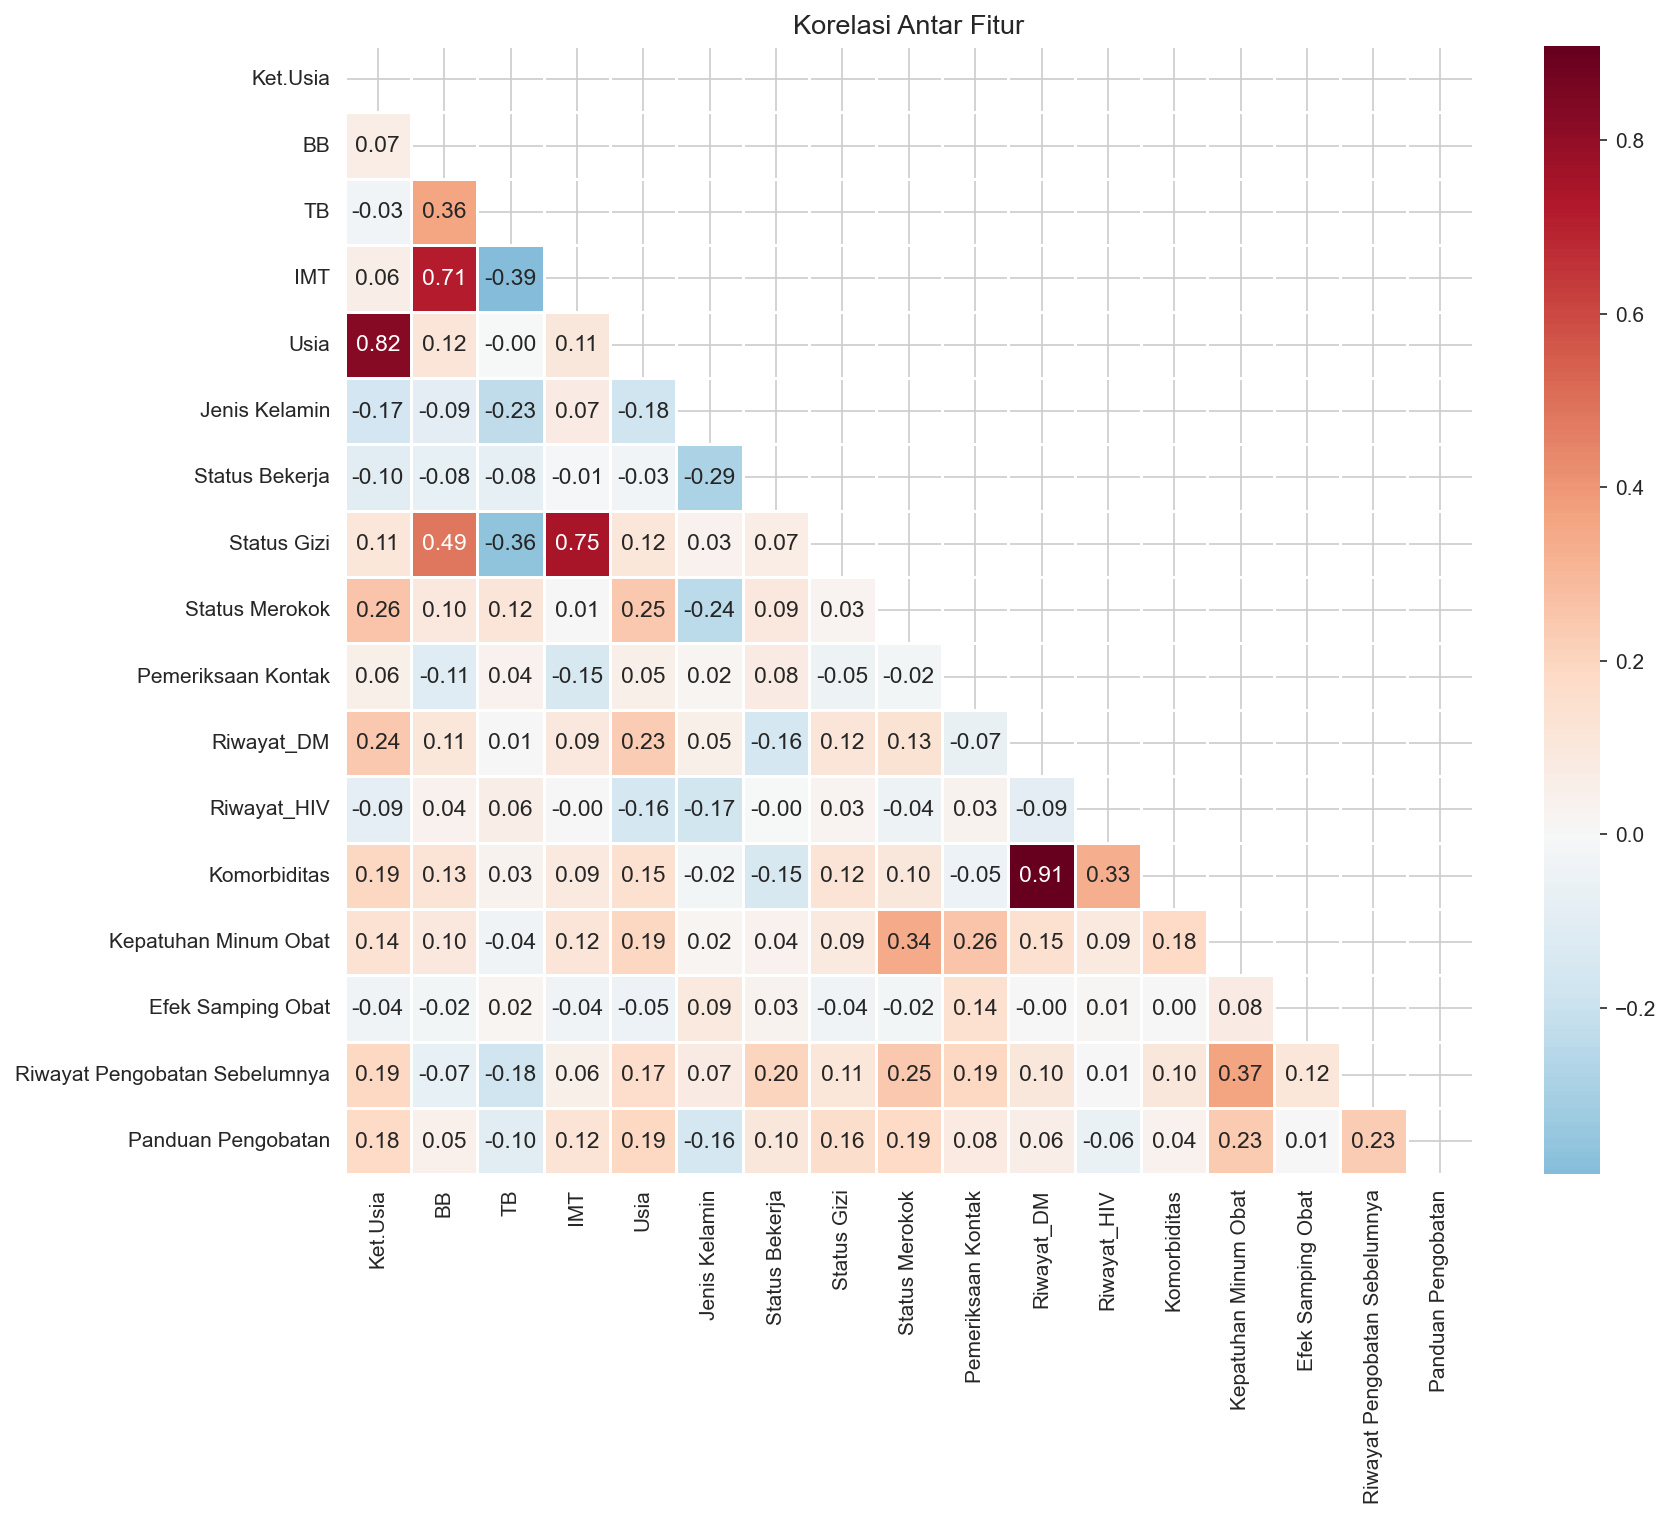

In [5]:
# Correlation heatmap (hanya fitur yang ditampilkan di web)
X_display = X.drop(columns=[c for c in HIDDEN_FEATURES if c in X.columns])
fig, ax = plt.subplots(figsize=(12, 10))
corr = X_display.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Korelasi Antar Fitur')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_correlation_heatmap.png')
plt.savefig(FIGURES_DIR / 'eda_correlation_heatmap.pdf')
plt.show()

## 3. Class Imbalance Analysis

Class counts: {'0': 105, '1': 46}
Percentages: {'0': 69.54, '1': 30.46}
Imbalance ratio: 2.28:1


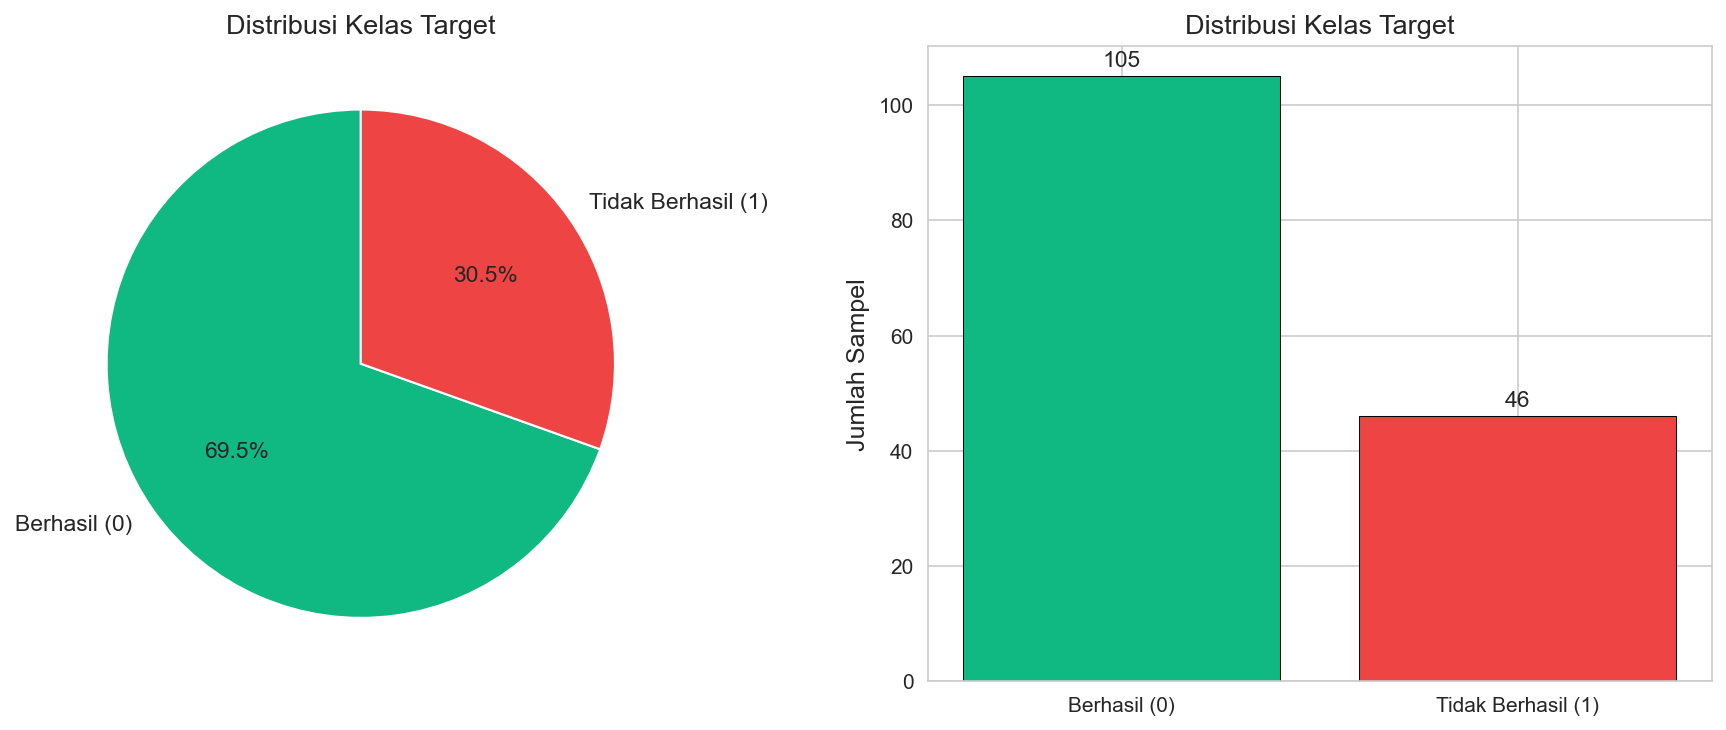

In [6]:
# Class distribution
class_dist = get_class_distribution(y)
print(f"Class counts: {class_dist['counts']}")
print(f"Percentages: {class_dist['percentages']}")
print(f"Imbalance ratio: {class_dist['imbalance_ratio']}:1")

label_map = {0: 'Berhasil (0)', 1: 'Tidak Berhasil (1)'}
counts = y.value_counts()
labels = [label_map.get(k, str(k)) for k in counts.index]
colors = ['#10b981', '#ef4444']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
axes[0].pie(counts.values, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 11})
axes[0].set_title('Distribusi Kelas Target')

# Bar chart
bars = axes[1].bar(labels, counts.values, color=colors, edgecolor='black', linewidth=0.5)
axes[1].set_ylabel('Jumlah Sampel')
axes[1].set_title('Distribusi Kelas Target')
for bar, val in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 str(val), ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'class_distribution.png')
plt.savefig(FIGURES_DIR / 'class_distribution.pdf')
plt.show()

## 4. Model Training & Evaluation

In [7]:
# Train all models (dengan SMOTE, sesuai konfigurasi web)
trainer = ModelTrainer(n_folds=5)
evaluator = ModelEvaluator()

training_results = trainer.train(X, y, use_smote=True)

X_train = training_results['X_train']
X_test = training_results['X_test']
y_train = training_results['y_train']
y_test = training_results['y_test']

print(f"\nTrain size (setelah SMOTE): {len(X_train)}, Test size: {len(X_test)}")
print(f"Best model: {training_results['best_model_name']}")
print(f"SMOTE applied: {training_results['smote_applied']}")

# Tampilkan CV F1-Score (sama seperti yang ditampilkan di web)
print(f"\n{'='*60}")
print("Perbandingan Skor F1 Cross Validation:")
print(f"(Angka ini yang ditampilkan di web)")
print(f"{'='*60}")
for name, cv in trainer.cv_results.items():
    f1_mean = cv['f1']['mean'] * 100
    f1_std = cv['f1']['std'] * 100
    print(f"  {name:30s} F1: {f1_mean:.2f}% (\u00b1{f1_std:.2f}%)")


=== Class Distribution ===
Original dataset: {0: 105, 1: 46} (total: 151)
Training set: {0: 73, 1: 32} (total: 105)
Training set size: 105
Validation set size: 23
Test set size: 23

=== SMOTE Applied ===
Training set after SMOTE: {0: 73, 1: 73} (total: 146)

=== Hyperparameter Tuning ===

Tuning Logistic Regression...
  Best params: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
  Best CV F1: 0.8966

Tuning Decision Tree...
  Best params: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
  Best CV F1: 0.8846

Tuning Support Vector Machine...
  Best params: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
  Best CV F1: 0.9019

=== Cross Validation ===

Cross-validating Logistic Regression...
  Accuracy: 0.9041 (+/- 0.0593)
  F1 Score: 0.8966 (+/- 0.0761)

Cross-validating Decision Tree...
  Accuracy: 0.8908 (+/- 0.0759)
  F1 Score: 0.8846 (+/- 0.0823)

Cross-validating Support Vector Machine...
  Accuracy: 0.9037 (+/- 0.0671)
  F1 Score: 0.9019 (+/- 0.

In [8]:
# Evaluate all models
eval_results = evaluator.evaluate_all_models(trainer.models, X_test, y_test)

# Comparison table
comparison = evaluator.evaluate_train_test(
    trainer.models, X_train, y_train, X_test, y_test
)

# Display metrics table
metrics_data = []
for name, res in eval_results.items():
    m = res['metrics']
    metrics_data.append({
        'Model': name,
        'Accuracy': f"{m['accuracy']*100:.2f}%",
        'Precision': f"{m['precision']*100:.2f}%",
        'Recall': f"{m['recall']*100:.2f}%",
        'F1-Score': f"{m['f1_score']*100:.2f}%",
        'Specificity': f"{m.get('specificity', 0)*100:.2f}%",
        'AUC-ROC': f"{m.get('auc_roc', 0)*100:.2f}%",
    })
pd.DataFrame(metrics_data)


=== Logistic Regression ===
Accuracy:  0.8261
Precision: 0.7143
Recall:    0.7143
F1 Score:  0.7143
Confusion Matrix: TP=5, TN=14, FP=2, FN=2

=== Decision Tree ===
Accuracy:  0.6522
Precision: 0.4286
Recall:    0.4286
F1 Score:  0.4286
Confusion Matrix: TP=3, TN=12, FP=4, FN=4

=== Support Vector Machine ===
Accuracy:  0.8261
Precision: 0.7143
Recall:    0.7143
F1 Score:  0.7143
Confusion Matrix: TP=5, TN=14, FP=2, FN=2

=== Logistic Regression (Train/Test Comparison) ===
  Accuracy:    Tr=96.58% | Ts=82.61%
  Sensitivity: Tr=97.26% | Ts=71.43%
  Specificity: Tr=95.89% | Ts=87.50%
  AUC-ROC:     Tr=99.21% | Ts=91.07%

=== Decision Tree (Train/Test Comparison) ===
  Accuracy:    Tr=100.00% | Ts=65.22%
  Sensitivity: Tr=100.00% | Ts=42.86%
  Specificity: Tr=100.00% | Ts=75.00%
  AUC-ROC:     Tr=100.00% | Ts=58.93%

=== Support Vector Machine (Train/Test Comparison) ===
  Accuracy:    Tr=98.63% | Ts=82.61%
  Sensitivity: Tr=98.63% | Ts=71.43%
  Specificity: Tr=98.63% | Ts=87.50%
  AUC-R

,Model,Accuracy,Precision,Recall,F1-Score,Specificity,AUC-ROC
0,Logistic Regression,82.61%,71.43%,71.43%,71.43%,87.50%,91.07%
1,Decision Tree,65.22%,42.86%,42.86%,42.86%,75.00%,58.93%
2,Support Vector Machine,82.61%,71.43%,71.43%,71.43%,87.50%,93.75%


## 5. Bootstrap 95% Confidence Intervals

In [9]:
# Bootstrap CI for all models
bootstrap_results = evaluator.get_all_bootstrap_ci(trainer.models, X_test, y_test, n_iter=1000)

ci_rows = []
for name, ci in bootstrap_results.items():
    row = {'Model': name}
    for metric, vals in ci.items():
        row[f'{metric}'] = f"{vals['mean']*100:.1f}% [{vals['ci_lower']*100:.1f}-{vals['ci_upper']*100:.1f}]"
    ci_rows.append(row)

ci_df = pd.DataFrame(ci_rows)
print("Bootstrap 95% Confidence Intervals (1000 iterations):")
ci_df

Bootstrap 95% Confidence Intervals (1000 iterations):


,Model,accuracy,precision,recall,f1_score,specificity,auc_roc
0,Logistic Regression,82.6% [65.2-95.7],71.1% [33.3-100.0],71.8% [33.3-100.0],69.9% [36.4-93.3],87.2% [68.8-100.0],91.0% [75.9-100.0]
1,Decision Tree,65.0% [43.5-82.6],42.6% [0.0-80.0],44.1% [0.0-83.3],41.5% [0.0-71.4],74.2% [52.6-93.8],59.1% [37.5-79.9]
2,Support Vector Machine,82.6% [65.2-95.7],71.1% [33.3-100.0],71.8% [33.3-100.0],69.9% [36.4-93.3],87.2% [68.8-100.0],93.6% [81.0-100.0]


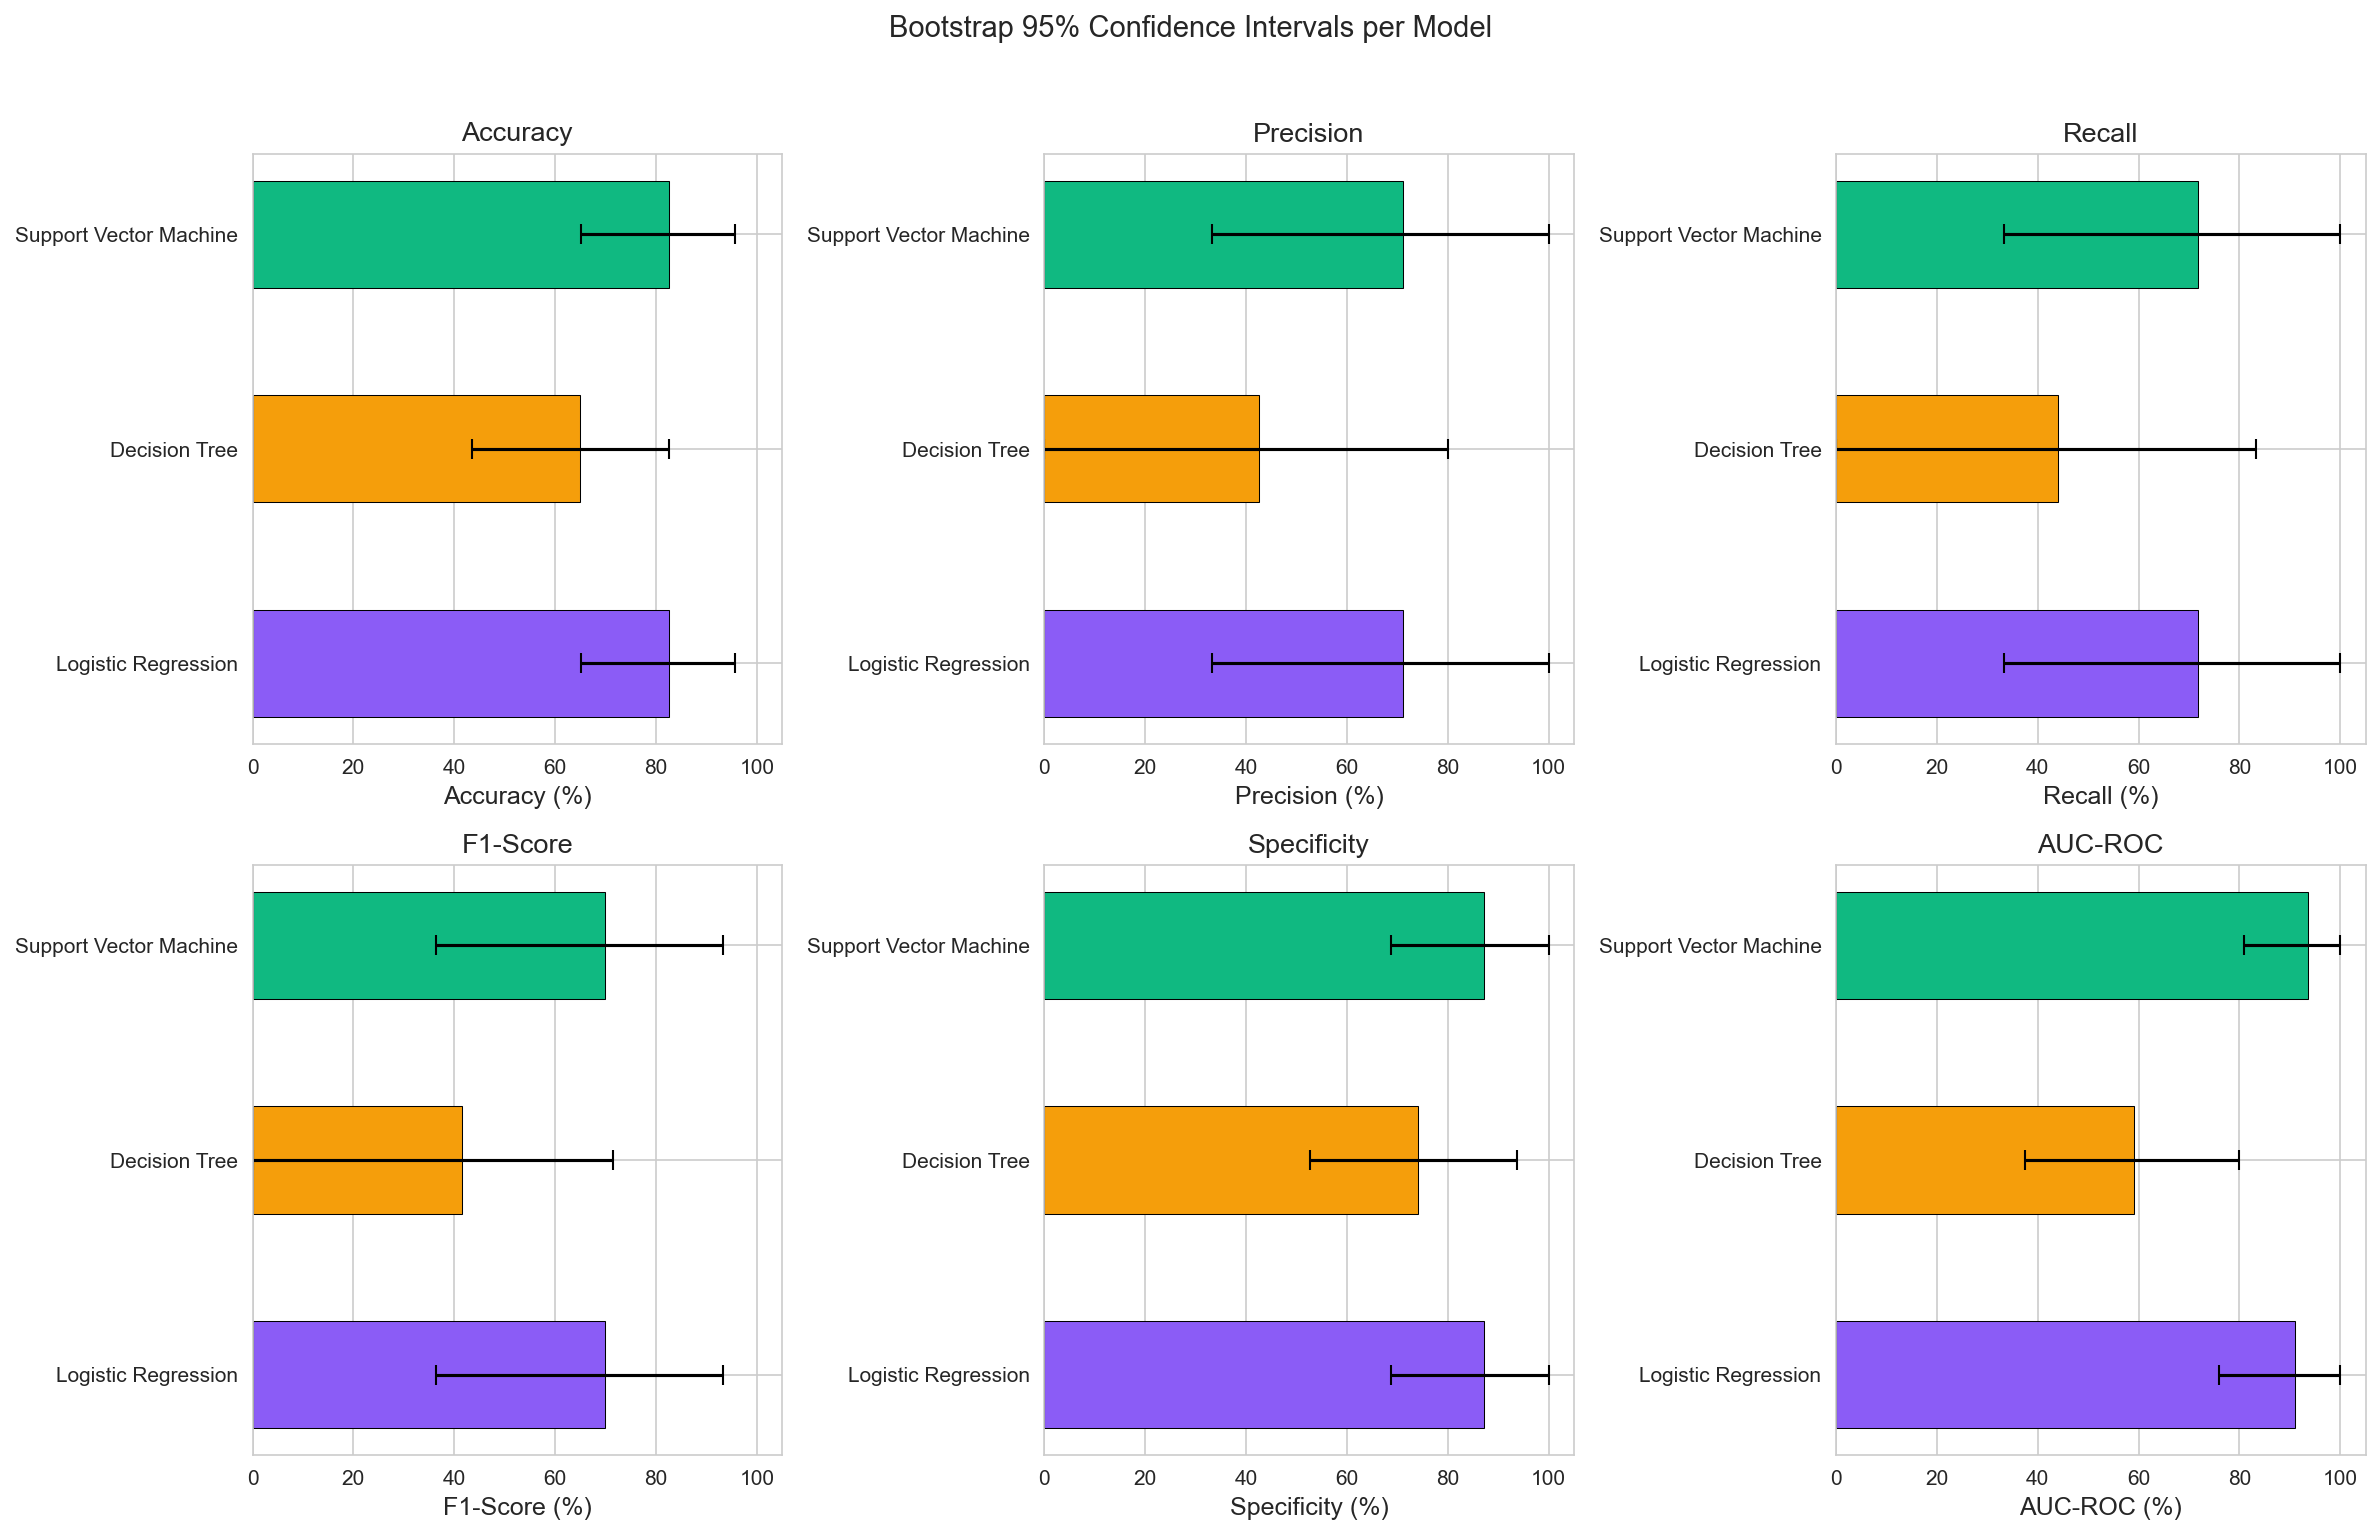

In [10]:
# Visualize bootstrap CI
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1_score', 'specificity', 'auc_roc']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Specificity', 'AUC-ROC']
model_colors = {'Logistic Regression': '#8b5cf6', 'Decision Tree': '#f59e0b', 'Support Vector Machine': '#10b981'}

for idx, (metric, label) in enumerate(zip(metrics_to_plot, metric_labels)):
    ax = axes[idx // 3][idx % 3]
    models = list(bootstrap_results.keys())
    means = [bootstrap_results[m][metric]['mean'] * 100 for m in models]
    ci_low = [bootstrap_results[m][metric]['ci_lower'] * 100 for m in models]
    ci_high = [bootstrap_results[m][metric]['ci_upper'] * 100 for m in models]
    errs = [[m - l for m, l in zip(means, ci_low)], [h - m for m, h in zip(means, ci_high)]]
    colors = [model_colors.get(m, '#6366f1') for m in models]

    bars = ax.barh(models, means, xerr=errs, color=colors, edgecolor='black',
                   linewidth=0.5, capsize=5, height=0.5)
    ax.set_xlabel(f'{label} (%)')
    ax.set_title(label)
    ax.set_xlim(0, 105)

plt.suptitle('Bootstrap 95% Confidence Intervals per Model', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'bootstrap_ci.png')
plt.savefig(FIGURES_DIR / 'bootstrap_ci.pdf')
plt.show()

## 6. ROC & Precision-Recall Curves

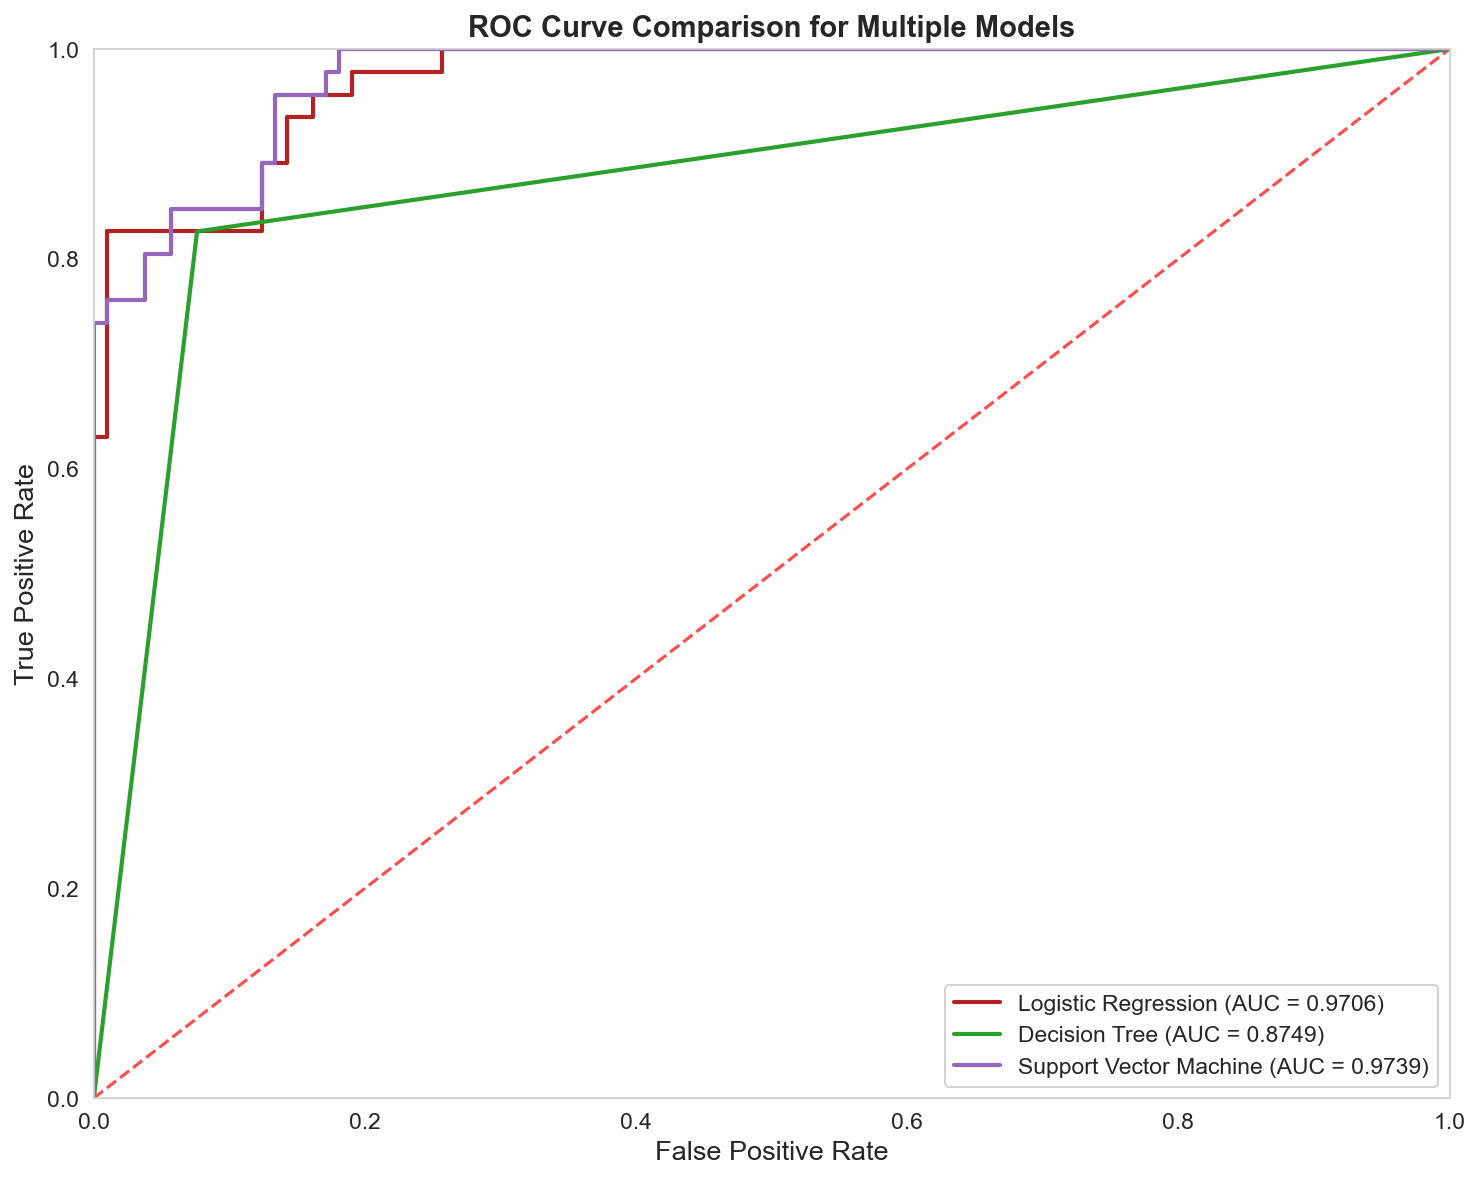

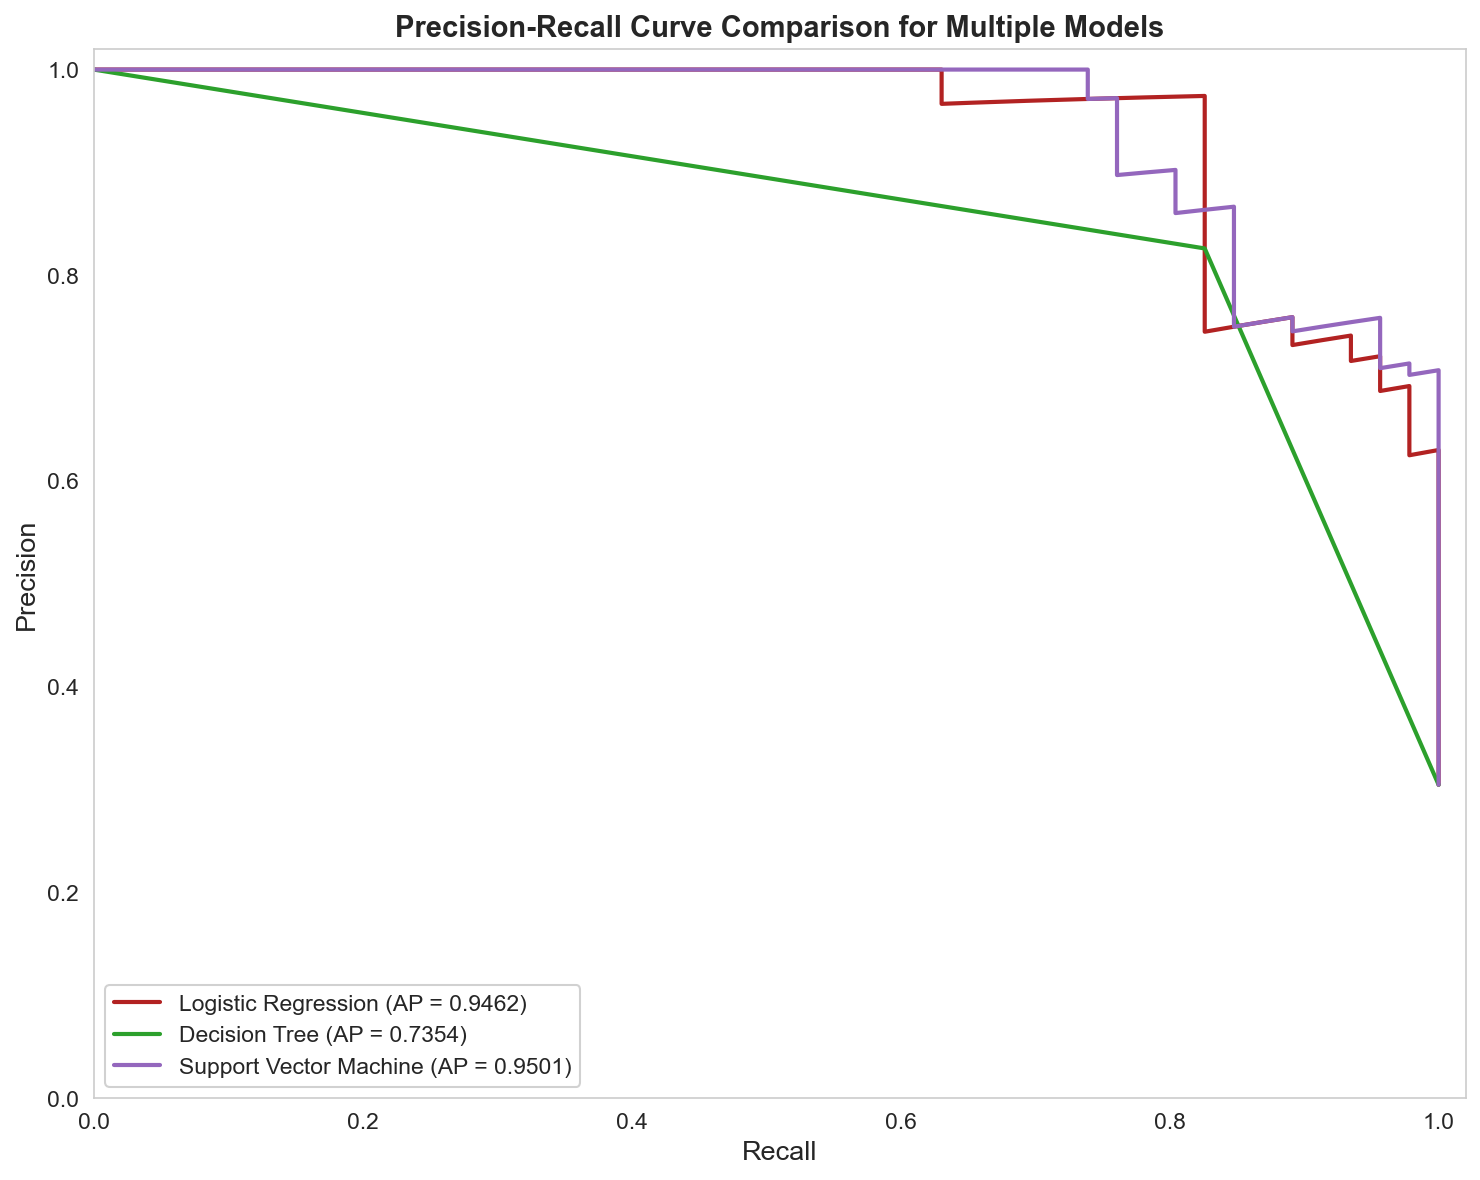

In [11]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict

model_colors = {
    'Logistic Regression': '#b22222',
    'Decision Tree': '#2ca02c',
    'Support Vector Machine': '#9467bd'
}

# === ROC Curve Comparison (using CV predictions for smooth curves) ===
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot([0, 1], [0, 1], color='red', linestyle='--', linewidth=1.5, alpha=0.7)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in trainer.models.items():
    # Cross-val predict gives predictions for all samples (smoother ROC)
    y_proba_cv = cross_val_predict(model, X, y, cv=cv, method='predict_proba', n_jobs=1)[:, 1]
    fpr, tpr, _ = roc_curve(y, y_proba_cv)
    auc = roc_auc_score(y, y_proba_cv)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})',
            color=model_colors.get(name, None), linewidth=2)

ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('ROC Curve Comparison for Multiple Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11, framealpha=0.9)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.0])
ax.tick_params(labelsize=11)
ax.grid(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'roc_curve_comparison.png')
plt.savefig(FIGURES_DIR / 'roc_curve_comparison.pdf')
plt.show()

# === Precision-Recall Curve Comparison (CV) ===
fig, ax = plt.subplots(figsize=(10, 8))

for name, model in trainer.models.items():
    y_proba_cv = cross_val_predict(model, X, y, cv=cv, method='predict_proba', n_jobs=1)[:, 1]
    prec, rec, _ = precision_recall_curve(y, y_proba_cv)
    ap = average_precision_score(y, y_proba_cv)
    ax.plot(rec, prec, label=f'{name} (AP = {ap:.4f})',
            color=model_colors.get(name, None), linewidth=2)

ax.set_xlabel('Recall', fontsize=13)
ax.set_ylabel('Precision', fontsize=13)
ax.set_title('Precision-Recall Curve Comparison for Multiple Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower left', fontsize=11, framealpha=0.9)
ax.set_xlim([0.0, 1.02])
ax.set_ylim([0.0, 1.02])
ax.tick_params(labelsize=11)
ax.grid(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'pr_curve_comparison.png')
plt.savefig(FIGURES_DIR / 'pr_curve_comparison.pdf')
plt.show()

## 7. Confusion Matrix Heatmaps

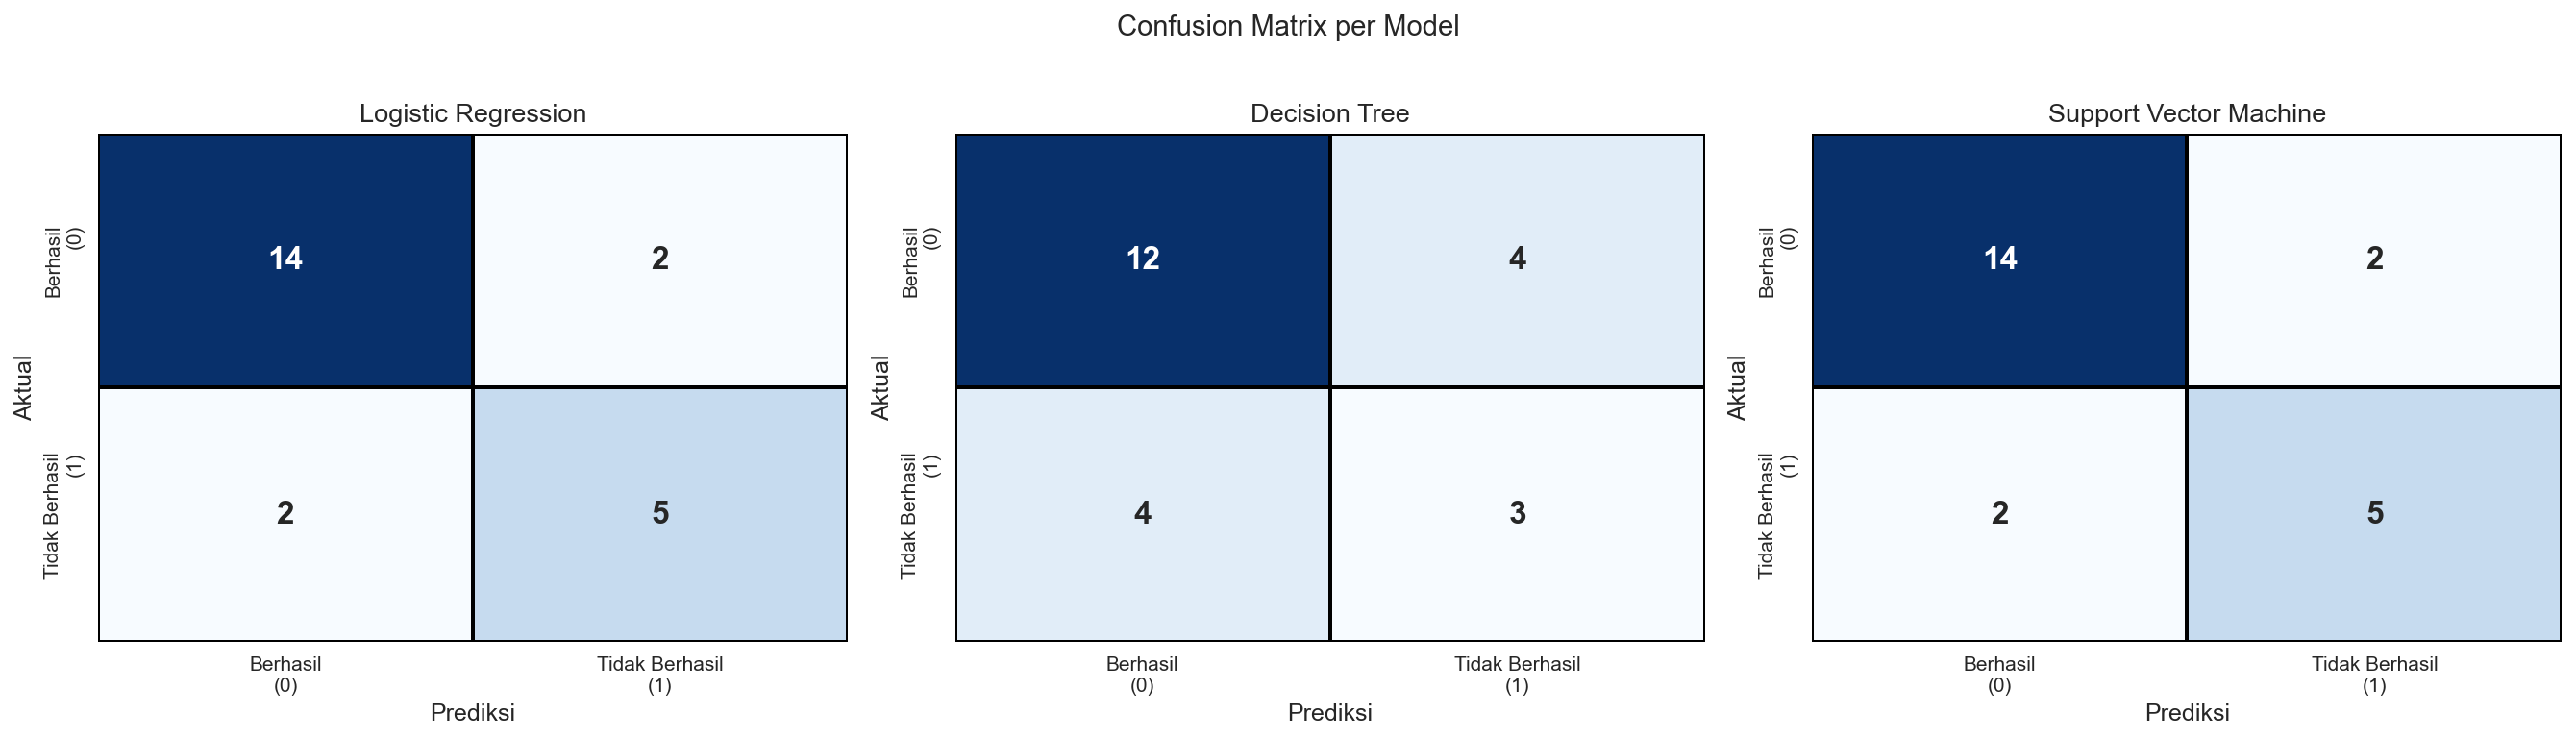

In [12]:
from sklearn.metrics import confusion_matrix as sk_confusion_matrix

n_models = len(trainer.models)
fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))
if n_models == 1:
    axes = [axes]

labels_display = ['Berhasil\n(0)', 'Tidak Berhasil\n(1)']

for idx, (name, model) in enumerate(trainer.models.items()):
    ax = axes[idx]
    y_pred = model.predict(X_test)
    cm = sk_confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=labels_display, yticklabels=labels_display,
                linewidths=1, linecolor='black', cbar=False,
                annot_kws={'size': 16, 'weight': 'bold'})
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')
    ax.set_title(f'{name}')

plt.suptitle('Confusion Matrix per Model', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'confusion_matrices.png')
plt.savefig(FIGURES_DIR / 'confusion_matrices.pdf')
plt.show()

## 8. Calibration Curves & Brier Scores

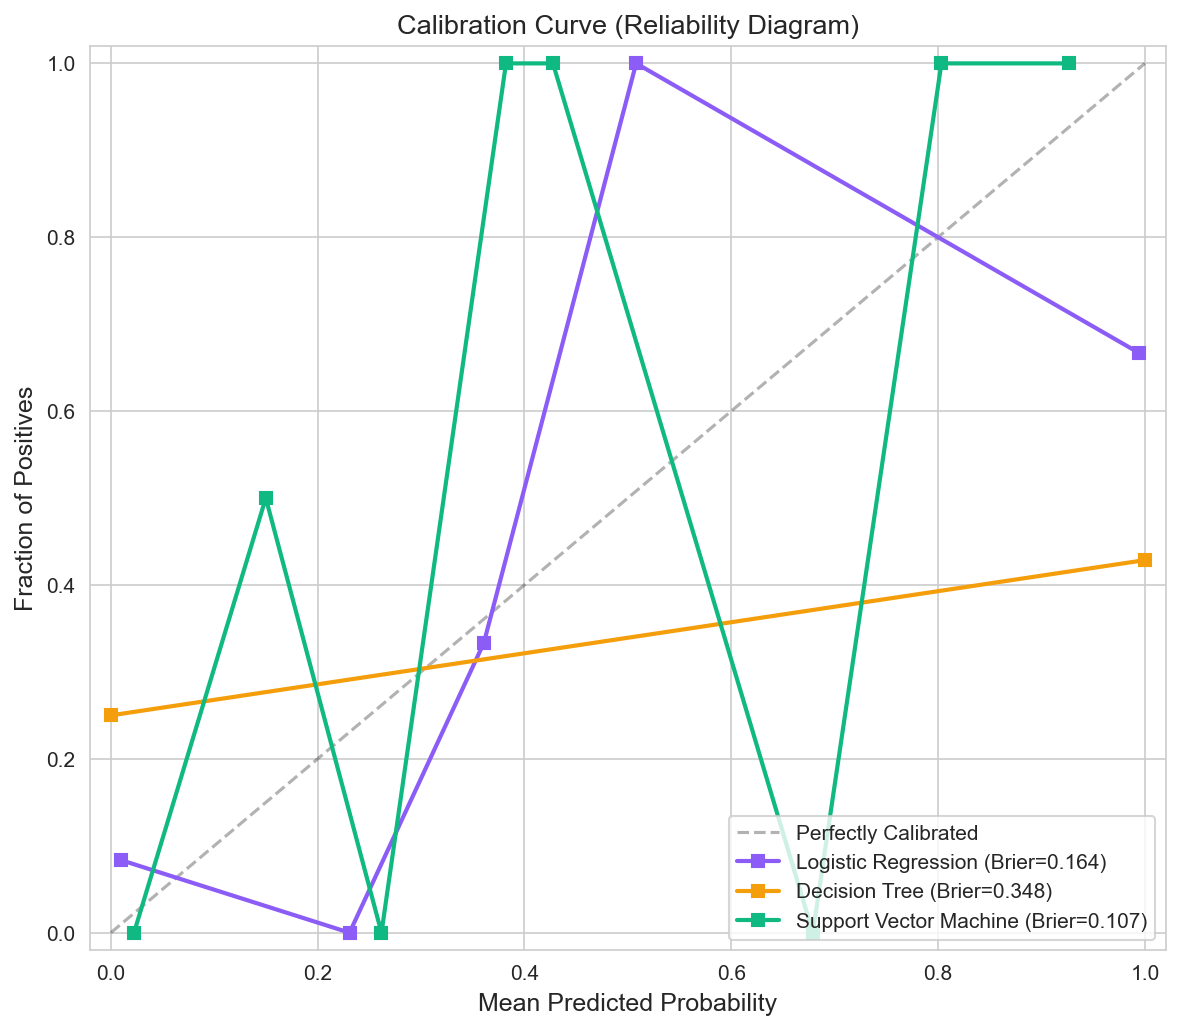


Brier Scores (lower is better):
  Logistic Regression: 0.1643
  Decision Tree: 0.3478
  Support Vector Machine: 0.1071


In [13]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

model_colors_cal = {
    'Logistic Regression': '#8b5cf6',
    'Decision Tree': '#f59e0b',
    'Support Vector Machine': '#10b981'
}

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Perfectly Calibrated')

brier_scores = {}
for name, model in trainer.models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10, strategy='uniform')
    brier = brier_score_loss(y_test, y_proba)
    brier_scores[name] = brier
    ax.plot(prob_pred, prob_true, 's-', label=f'{name} (Brier={brier:.3f})',
            color=model_colors_cal.get(name, None), linewidth=2, markersize=6)

ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('Calibration Curve (Reliability Diagram)')
ax.legend(loc='lower right')
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'calibration_curves.png')
plt.savefig(FIGURES_DIR / 'calibration_curves.pdf')
plt.show()

print("\nBrier Scores (lower is better):")
for name, score in brier_scores.items():
    print(f"  {name}: {score:.4f}")

In [14]:
## 9. Feature Importance & Odds Ratio Forest Plot

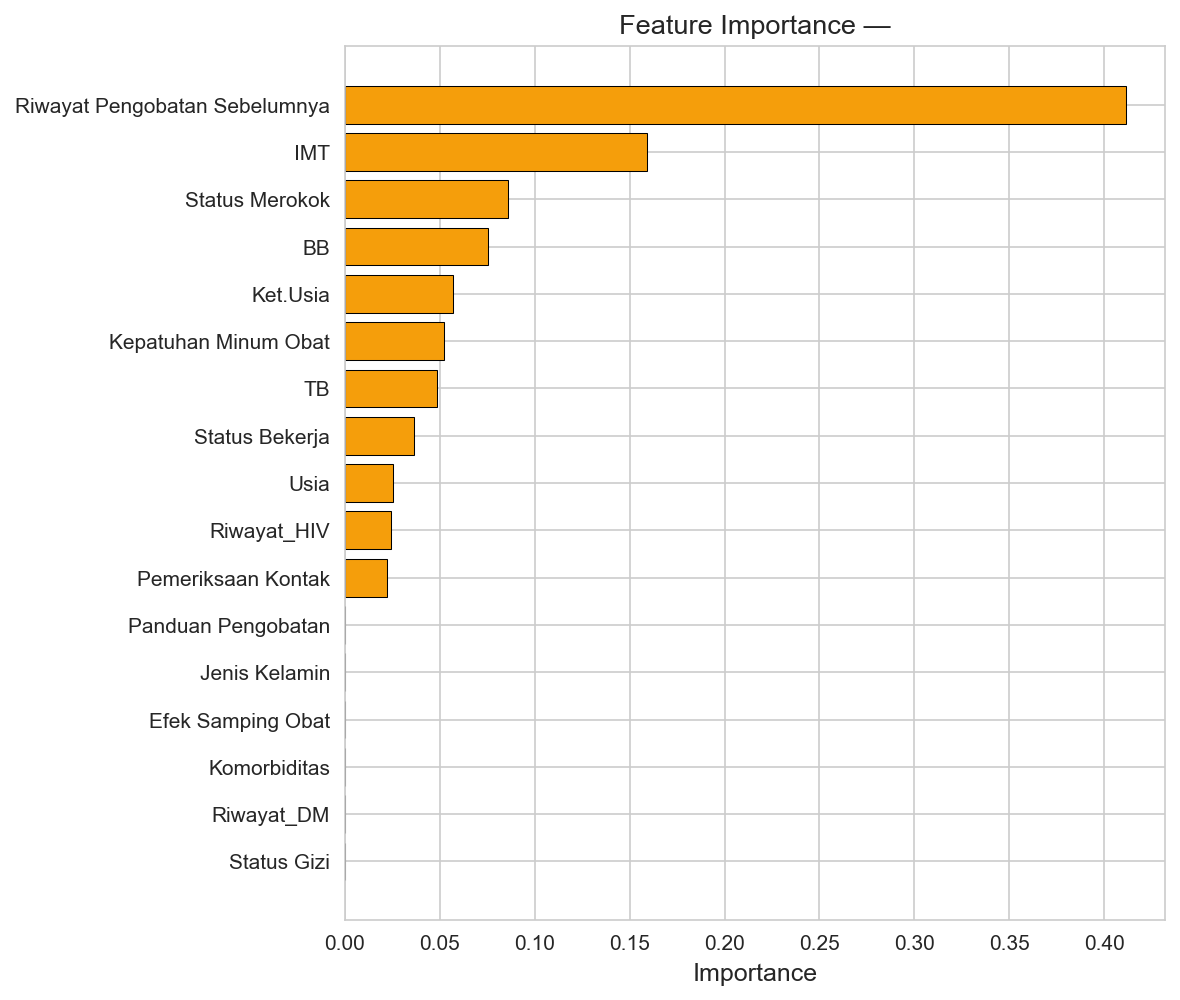

In [22]:
feature_names = list(X_test.columns)
interp = get_all_interpretability(trainer.models, X_test, y_test, feature_names)

# Decision Tree Feature Importance
dt_key = [k for k in interp if 'Decision Tree' in k]
if dt_key:
    fi = interp[dt_key[0]].get('feature_importance', [])
    if fi:
        fi_df = pd.DataFrame(fi).sort_values('importance', ascending=True)
        fi_df = fi_df[~fi_df['feature'].isin(HIDDEN_FEATURES)]

        fig, ax = plt.subplots(figsize=(8, max(5, len(fi_df) * 0.4)))
        bars = ax.barh(fi_df['feature'], fi_df['importance'], color='#f59e0b',
                       edgecolor='black', linewidth=0.5)
        ax.set_xlabel('Importance')
        ax.set_title('Feature Importance \u2014 Decision Tree')
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / 'feature_importance_dt.png')
        plt.savefig(FIGURES_DIR / 'feature_importance_dt.pdf')
        plt.show()

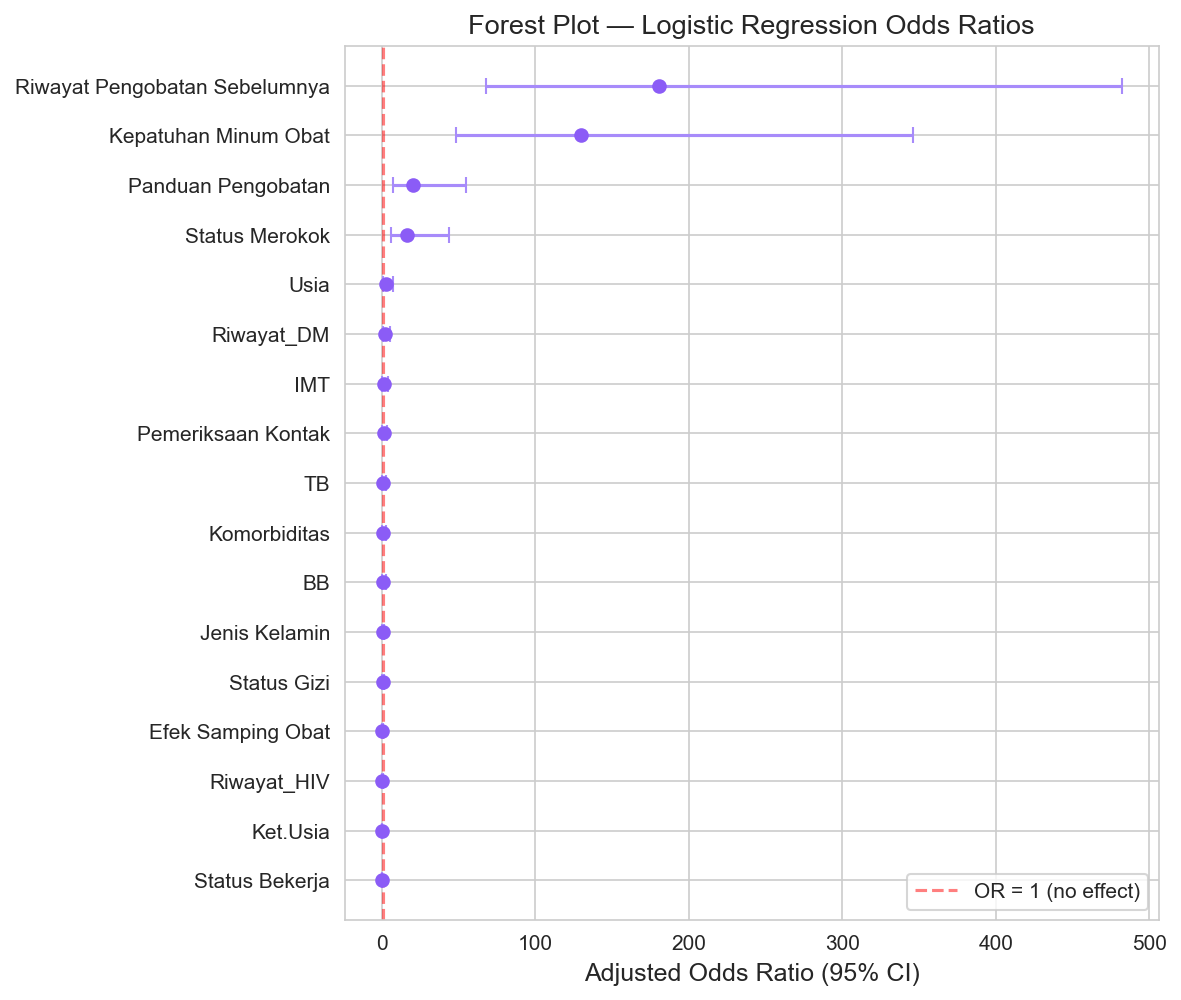


Odds Ratio Table:
                      feature  odds_ratio  ci_lower   ci_upper      p_value  significant
               Status Bekerja    0.123091  0.046198   0.327971 2.793762e-05         True
                     Ket.Usia    0.236748  0.088854   0.630806 3.957679e-03         True
                  Riwayat_HIV    0.242322  0.090946   0.645656 4.582892e-03         True
            Efek Samping Obat    0.411638  0.154492   1.096793 7.586159e-02        False
                  Status Gizi    0.655509  0.246020   1.746576 3.982866e-01        False
                Jenis Kelamin    0.657970  0.246943   1.753131 4.024840e-01        False
                           BB    1.000000  0.375311   2.664456 1.000000e+00        False
                 Komorbiditas    1.000000  0.375311   2.664456 1.000000e+00        False
                           TB    1.171351  0.439621   3.121014 7.517627e-01        False
           Pemeriksaan Kontak    1.347314  0.505662   3.589858 5.510247e-01        False
  

In [16]:
# Logistic Regression Odds Ratio Forest Plot
lr_key = [k for k in interp if 'Logistic Regression' in k]
if lr_key:
    ors = interp[lr_key[0]].get('odds_ratios', [])
    if ors:
        or_df = pd.DataFrame(ors).sort_values('odds_ratio', ascending=True)
        or_df = or_df[~or_df['feature'].isin(HIDDEN_FEATURES)]

        fig, ax = plt.subplots(figsize=(8, max(5, len(or_df) * 0.4)))
        y_pos = range(len(or_df))

        # Plot CI as horizontal error bars
        ax.errorbar(or_df['odds_ratio'], y_pos,
                     xerr=[or_df['odds_ratio'] - or_df['ci_lower'],
                           or_df['ci_upper'] - or_df['odds_ratio']],
                     fmt='o', color='#8b5cf6', ecolor='#a78bfa',
                     capsize=4, markersize=6, linewidth=1.5)

        # Reference line at OR=1
        ax.axvline(x=1, color='red', linestyle='--', alpha=0.5, label='OR = 1 (no effect)')

        ax.set_yticks(list(y_pos))
        ax.set_yticklabels(or_df['feature'])
        ax.set_xlabel('Adjusted Odds Ratio (95% CI)')
        ax.set_title('Forest Plot \u2014 Logistic Regression Odds Ratios')
        ax.legend(loc='lower right')

        plt.tight_layout()
        plt.savefig(FIGURES_DIR / 'odds_ratio_forest_plot.png')
        plt.savefig(FIGURES_DIR / 'odds_ratio_forest_plot.pdf')
        plt.show()

        # Display OR table
        print("\nOdds Ratio Table:")
        or_table = or_df[['feature', 'odds_ratio', 'ci_lower', 'ci_upper', 'p_value', 'significant']]
        print(or_table.to_string(index=False))

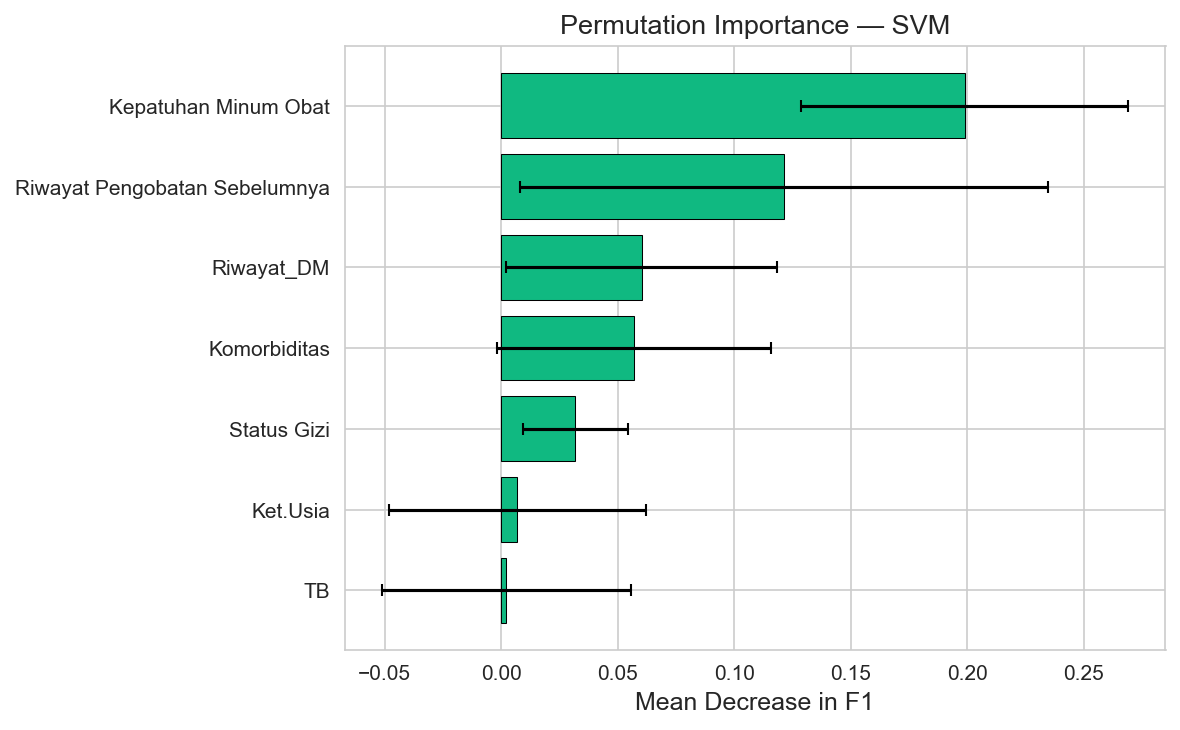

In [17]:
# Permutation Importance for SVM
svm_key = [k for k in interp if 'Support Vector Machine' in k]
if svm_key:
    pi = interp[svm_key[0]].get('permutation_importance', [])
    if pi:
        pi_df = pd.DataFrame(pi).sort_values('importance_mean', ascending=True)
        pi_df = pi_df[~pi_df['feature'].isin(HIDDEN_FEATURES)]
        pi_df = pi_df[pi_df['importance_mean'] > 0]

        if len(pi_df) > 0:
            fig, ax = plt.subplots(figsize=(8, max(5, len(pi_df) * 0.4)))
            ax.barh(pi_df['feature'], pi_df['importance_mean'],
                    xerr=pi_df['importance_std'], color='#10b981',
                    edgecolor='black', linewidth=0.5, capsize=3)
            ax.set_xlabel('Mean Decrease in F1')
            ax.set_title('Permutation Importance \u2014 SVM')
            plt.tight_layout()
            plt.savefig(FIGURES_DIR / 'permutation_importance_svm.png')
            plt.savefig(FIGURES_DIR / 'permutation_importance_svm.pdf')
            plt.show()

## 10. SHAP Interpretability

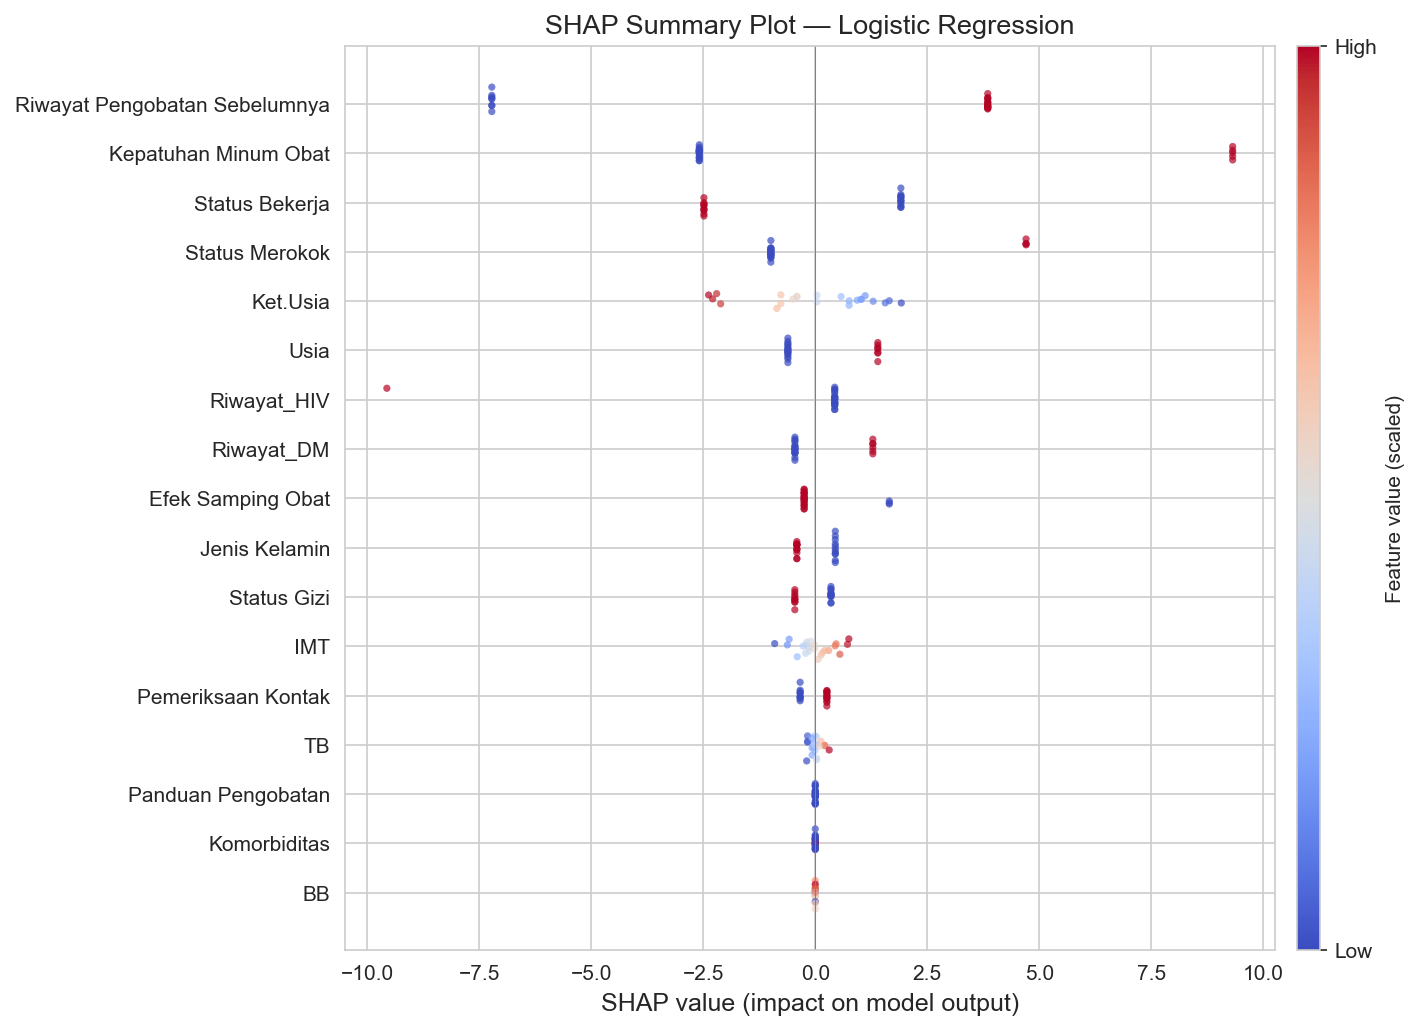

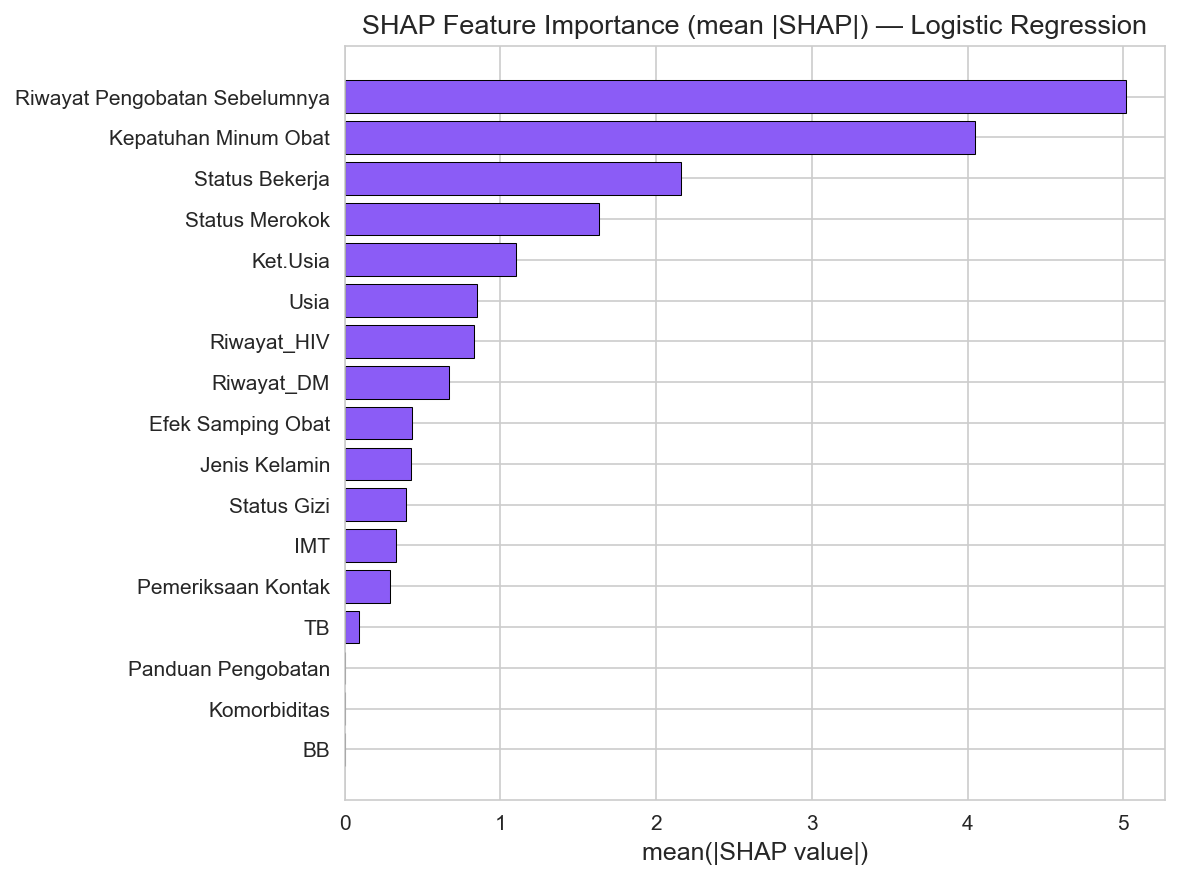

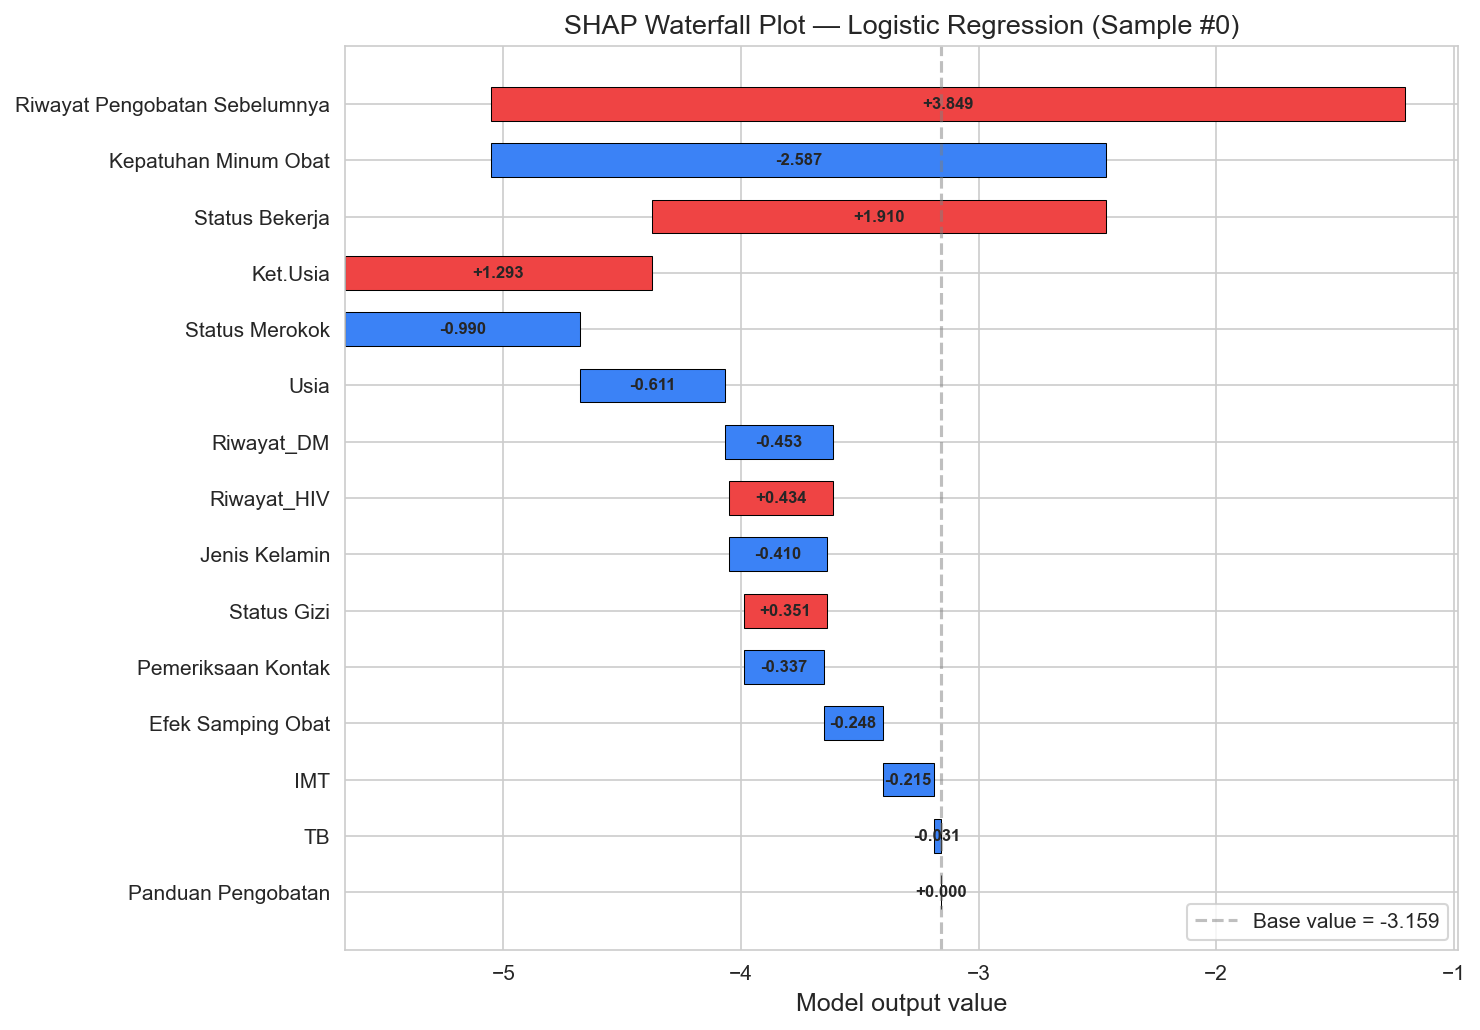

SHAP analysis complete (analytical computation for linear model).


In [18]:
# SHAP values for Logistic Regression (exact analytical computation for linear models)
# For linear models: phi_i(x) = beta_i * (x_i - E[x_i])
# This is mathematically equivalent to shap.LinearExplainer

lr_key = [k for k in trainer.models if 'Logistic Regression' in k]
if lr_key:
    lr_model = trainer.models[lr_key[0]]
    X_test_df = pd.DataFrame(X_test, columns=feature_names)

    # Get scaled data and model coefficients
    scaler = lr_model.named_steps['scaler']
    classifier = lr_model.named_steps['classifier']
    X_scaled = scaler.transform(X_test_df)
    X_scaled_mean = X_scaled.mean(axis=0)
    coefs = classifier.coef_[0]

    # Compute exact SHAP values: phi_i = beta_i * (x_i - E[x_i])
    shap_values = np.array([(X_scaled[i] - X_scaled_mean) * coefs for i in range(len(X_scaled))])
    base_value = classifier.intercept_[0] + np.dot(X_scaled_mean, coefs)

    # Filter out hidden features from SHAP visualization
    visible_mask = [i for i, fn in enumerate(feature_names) if fn not in HIDDEN_FEATURES]
    shap_values = shap_values[:, visible_mask]
    X_scaled = X_scaled[:, visible_mask]
    feature_names_display = [feature_names[i] for i in visible_mask]
    # Use filtered names for all plots below
    feature_names = feature_names_display

    # --- 1. Summary Plot (beeswarm-style with color = feature value) ---
    fig, ax = plt.subplots(figsize=(10, 7))
    mean_abs_shap = np.mean(np.abs(shap_values), axis=0)
    sorted_idx = np.argsort(mean_abs_shap)

    cmap = plt.cm.coolwarm
    for pos, idx in enumerate(sorted_idx):
        vals = shap_values[:, idx]
        feat_vals = X_scaled[:, idx]
        norm_feat = (feat_vals - feat_vals.min()) / (feat_vals.max() - feat_vals.min() + 1e-10)
        colors_arr = cmap(norm_feat)
        jitter = np.random.normal(0, 0.12, size=len(vals))
        ax.scatter(vals, [pos] * len(vals) + jitter, c=colors_arr, s=12, alpha=0.7, edgecolors='none')

    ax.set_yticks(range(len(sorted_idx)))
    ax.set_yticklabels([feature_names[i] for i in sorted_idx])
    ax.set_xlabel('SHAP value (impact on model output)')
    ax.axvline(x=0, color='gray', linewidth=0.5)
    ax.set_title('SHAP Summary Plot \u2014 Logistic Regression')
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, pad=0.02, aspect=40)
    cbar.set_label('Feature value (scaled)', fontsize=10)
    cbar.set_ticks([0, 1])
    cbar.set_ticklabels(['Low', 'High'])
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'shap_summary_lr.png')
    plt.savefig(FIGURES_DIR / 'shap_summary_lr.pdf')
    plt.show()

    # --- 2. Bar Plot (mean |SHAP|) ---
    fig, ax = plt.subplots(figsize=(8, 6))
    sorted_idx_bar = np.argsort(mean_abs_shap)
    ax.barh([feature_names[i] for i in sorted_idx_bar],
            mean_abs_shap[sorted_idx_bar],
            color='#8b5cf6', edgecolor='black', linewidth=0.5)
    ax.set_xlabel('mean(|SHAP value|)')
    ax.set_title('SHAP Feature Importance (mean |SHAP|) \u2014 Logistic Regression')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'shap_bar_lr.png')
    plt.savefig(FIGURES_DIR / 'shap_bar_lr.pdf')
    plt.show()

    # --- 3. Waterfall Plot for first test sample ---
    sample_idx = 0
    sample_shap = shap_values[sample_idx]
    sorted_wf = np.argsort(np.abs(sample_shap))
    top_n = min(15, len(feature_names))
    top_idx = sorted_wf[-top_n:]

    fig, ax = plt.subplots(figsize=(10, 7))
    cumulative = base_value
    y_positions = []
    y_labels = []
    lefts = []
    widths = []
    colors_wf = []

    for rank, fi in enumerate(top_idx):
        y_positions.append(rank)
        y_labels.append(feature_names[fi])
        val = sample_shap[fi]
        lefts.append(cumulative if val > 0 else cumulative + val)
        widths.append(abs(val))
        colors_wf.append('#ef4444' if val > 0 else '#3b82f6')
        cumulative += val

    ax.barh(y_positions, widths, left=lefts, color=colors_wf, edgecolor='black', linewidth=0.5, height=0.6)
    for i, (l, w, val_idx) in enumerate(zip(lefts, widths, top_idx)):
        val = sample_shap[val_idx]
        ax.text(l + w / 2, i, f'{val:+.3f}', ha='center', va='center', fontsize=8, fontweight='bold')

    ax.set_yticks(y_positions)
    ax.set_yticklabels(y_labels)
    ax.axvline(x=base_value, color='gray', linestyle='--', alpha=0.5, label=f'Base value = {base_value:.3f}')
    ax.set_xlabel('Model output value')
    ax.set_title('SHAP Waterfall Plot \u2014 Logistic Regression (Sample #0)')
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'shap_waterfall_lr.png')
    plt.savefig(FIGURES_DIR / 'shap_waterfall_lr.pdf')
    plt.show()

    print("SHAP analysis complete (analytical computation for linear model).")
else:
    print("No Logistic Regression model found.")

## 11. Nested Cross-Validation

In [19]:
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Nested CV: outer=5 folds, inner=3 folds
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

models_config = {
    'Logistic Regression': {
        'pipeline': Pipeline([('scaler', StandardScaler()),
                              ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))]),
        'params': {'classifier__C': [0.01, 0.1, 1, 10, 100], 'classifier__penalty': ['l1', 'l2'], 'classifier__solver': ['liblinear']}
    },
    'Decision Tree': {
        'pipeline': Pipeline([('scaler', StandardScaler()),
                              ('classifier', DecisionTreeClassifier(random_state=42))]),
        'params': {'classifier__max_depth': [3, 5, 7, 10, None], 'classifier__min_samples_split': [2, 5, 10]}
    },
    'SVM': {
        'pipeline': Pipeline([('scaler', StandardScaler()),
                              ('classifier', SVC(probability=True, class_weight='balanced', random_state=42))]),
        'params': {'classifier__C': [0.1, 1, 10], 'classifier__kernel': ['rbf', 'linear']}
    },
}

nested_results = {}
for name, cfg in models_config.items():
    print(f"\nNested CV for {name}...")
    inner_search = GridSearchCV(cfg['pipeline'], cfg['params'], cv=inner_cv, scoring='f1', n_jobs=1)
    outer_scores = cross_val_score(inner_search, X, y, cv=outer_cv, scoring='f1', n_jobs=1)
    nested_results[name] = {
        'mean': outer_scores.mean(),
        'std': outer_scores.std(),
        'scores': outer_scores.tolist()
    }
    print(f"  F1 = {outer_scores.mean():.4f} +/- {outer_scores.std():.4f}")
    print(f"  Fold scores: {[f'{s:.4f}' for s in outer_scores]}")

print("\n=== Nested CV Summary ===")
nested_df = pd.DataFrame([
    {'Model': n, 'F1 (mean+/-std)': f"{r['mean']*100:.2f}% +/- {r['std']*100:.2f}%"}
    for n, r in nested_results.items()
])
nested_df


Nested CV for Logistic Regression...
  F1 = 0.8358 +/- 0.1154
  Fold scores: ['0.8333', '0.6154', '0.9412', '0.8889', '0.9000']

Nested CV for Decision Tree...
  F1 = 0.8071 +/- 0.1229
  Fold scores: ['0.8000', '0.5714', '0.8750', '0.8889', '0.9000']

Nested CV for SVM...
  F1 = 0.7999 +/- 0.1007
  Fold scores: ['0.7826', '0.6154', '0.8889', '0.8235', '0.8889']

=== Nested CV Summary ===


,Model,F1 (mean+/-std)
0,Logistic Regression,83.58% +/- 11.54%
1,Decision Tree,80.71% +/- 12.29%
2,SVM,79.99% +/- 10.07%


## 12. Sensitivity Analysis

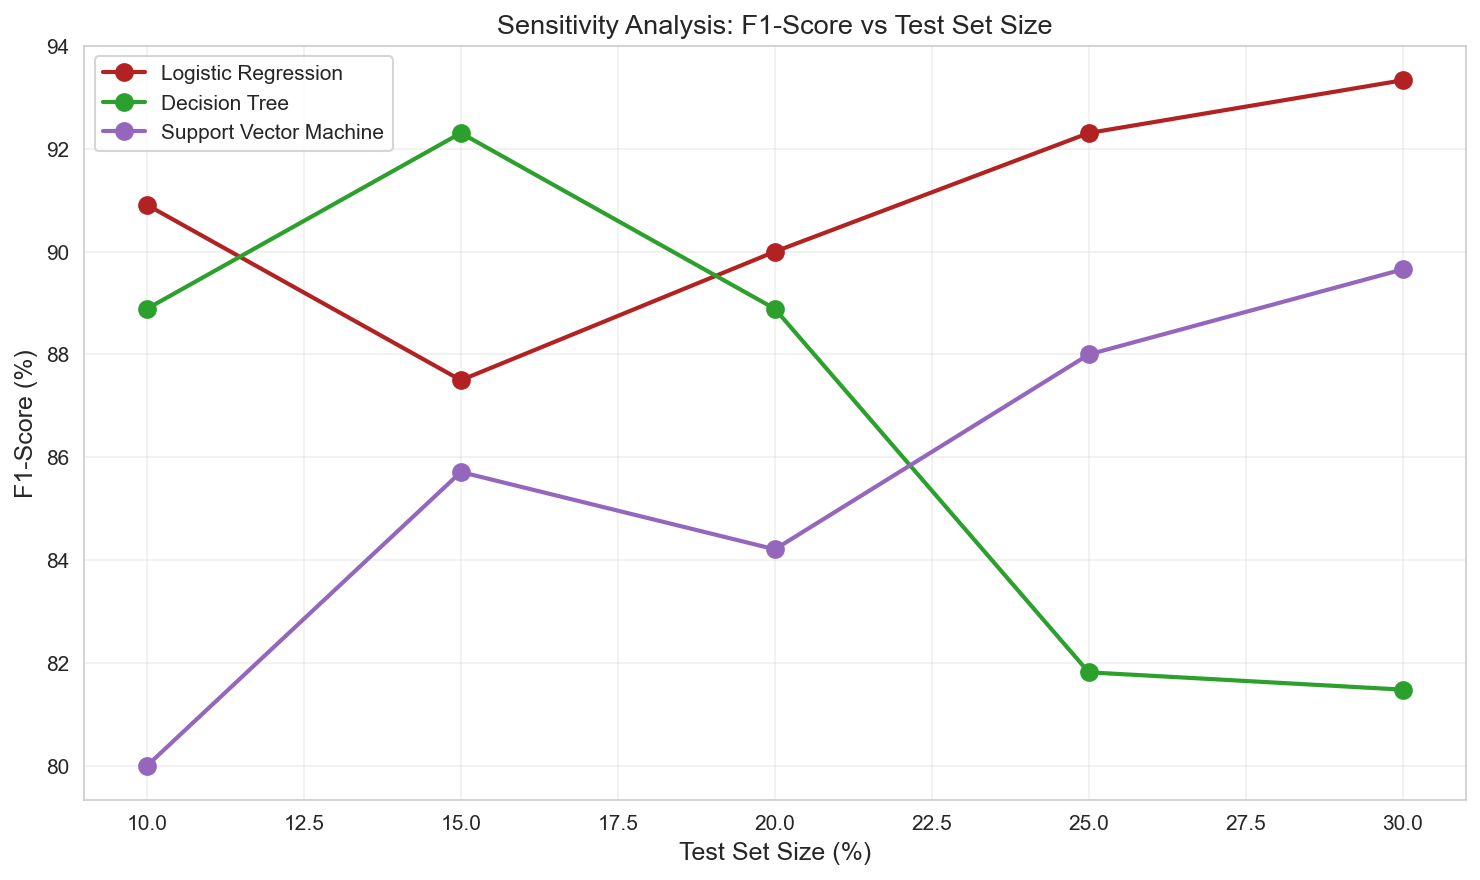


=== Class Distribution ===
Original dataset: {0: 105, 1: 46} (total: 151)
Training set: {0: 73, 1: 32} (total: 105)
Training set size: 105
Validation set size: 23
Test set size: 23

=== SMOTE Applied ===
Training set after SMOTE: {0: 73, 1: 73} (total: 146)

=== Hyperparameter Tuning ===

Tuning Logistic Regression...
  Best params: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
  Best CV F1: 0.8966

Tuning Decision Tree...
  Best params: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
  Best CV F1: 0.8846

Tuning Support Vector Machine...
  Best params: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
  Best CV F1: 0.9019

=== Cross Validation ===

Cross-validating Logistic Regression...
  Accuracy: 0.9041 (+/- 0.0593)
  F1 Score: 0.8966 (+/- 0.0761)

Cross-validating Decision Tree...
  Accuracy: 0.8908 (+/- 0.0759)
  F1 Score: 0.8846 (+/- 0.0823)

Cross-validating Support Vector Machine...
  Accuracy: 0.9037 (+/- 0.0671)
  F1 Score: 0.9019 (+/- 0.

In [20]:
# Test with different train/test ratios
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

ratios = [0.1, 0.15, 0.2, 0.25, 0.3]
sensitivity_results = {name: [] for name in trainer.models}

for test_ratio in ratios:
    X_tr, X_ts, y_tr, y_ts = train_test_split(
        X, y, test_size=test_ratio, random_state=42, stratify=y
    )
    for name, model in trainer.models.items():
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_ts)
        f1 = f1_score(y_ts, y_pred, zero_division=0)
        sensitivity_results[name].append(f1)

fig, ax = plt.subplots(figsize=(10, 6))
for name, scores in sensitivity_results.items():
    ax.plot([r*100 for r in ratios], [s*100 for s in scores], 'o-',
            label=name, color=model_colors.get(name, None), linewidth=2, markersize=8)

ax.set_xlabel('Test Set Size (%)')
ax.set_ylabel('F1-Score (%)')
ax.set_title('Sensitivity Analysis: F1-Score vs Test Set Size')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'sensitivity_analysis.png')
plt.savefig(FIGURES_DIR / 'sensitivity_analysis.pdf')
plt.show()

# Re-train with original split to restore model state (dengan SMOTE, sesuai web)
training_results = trainer.train(X, y, use_smote=True)
print("Models re-trained with original split (SMOTE enabled).")

## 13. Export All Figures \u2014 Summary

In [21]:
# List all generated figures
import glob
figures = sorted(glob.glob(str(FIGURES_DIR / '*')))
print(f"Total figures generated: {len(figures)}")
print()
for f in figures:
    size_kb = os.path.getsize(f) / 1024
    print(f"  {os.path.basename(f):45s} {size_kb:7.1f} KB")

print(f"\nAll figures saved to: {FIGURES_DIR.resolve()}")
print("PNG files are suitable for Word/PowerPoint embedding.")
print("PDF files are suitable for LaTeX embedding.")

Total figures generated: 40

  bootstrap_ci.pdf                                 20.4 KB
  bootstrap_ci.png                                229.4 KB
  calibration_curves.pdf                           18.6 KB
  calibration_curves.png                          307.1 KB
  class_distribution.pdf                           16.0 KB
  class_distribution.png                          127.3 KB
  confusion_matrices.pdf                           17.7 KB
  confusion_matrices.png                          127.1 KB
  eda_correlation_heatmap.pdf                      31.5 KB
  eda_correlation_heatmap.png                     578.3 KB
  feature_importance_dt.pdf                        19.3 KB
  feature_importance_dt.png                       139.4 KB
  odds_ratio_forest_plot.pdf                       23.0 KB
  odds_ratio_forest_plot.png                      174.5 KB
  permutation_importance_svm.pdf                   17.5 KB
  permutation_importance_svm.png                   87.3 KB
  pr_curve_comparison.pdf  